# Spatial Analysis & Map Visualizations
## Geographic distribution of model performance in Jotunheimen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
import geopandas as gpd
import xarray as xr
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

## 1. Load Data

In [2]:
# Load validation results
validation_results = pd.read_csv('../data/processed/multi_station_validation_results.csv')

# Load GIS data if available
try:
    regions_gdf = gpd.read_file('../data/GIS/forecasting_regions_wgs84.geojson')
    print(f"✓ Forecasting regions loaded: {len(regions_gdf)} regions")
except:
    print("✗ Could not load forecasting regions")
    regions_gdf = None

try:
    pixels_gdf = gpd.read_file('../data/GIS/pixels_utm.geojson')
    print(f"✓ Pixels loaded: {len(pixels_gdf)} pixels")
except:
    print("✗ Could not load pixels")
    pixels_gdf = None

print(f"\nValidation results: {len(validation_results)} stations")
print(f"Columns: {list(validation_results.columns[:5])}...")

✓ Forecasting regions loaded: 48 regions
✓ Pixels loaded: 1041 pixels

Validation results: 11 stations
Columns: ['Station', 'Station_Code', 'N_Days', 'Period_Start', 'Period_End']...


## 2. Prepare Station Location Data

In [3]:
# Check if we have coordinate information
print("Validation results columns:")
print(validation_results.columns.tolist())

# If we don't have coordinates, we'll need to estimate from station names or use json
# For now, let's see what's available
print("\nFirst few rows:")
print(validation_results[['Station', 'Station_Code', 'FSM2_RMSE', 'seNorge_RMSE']].head())

Validation results columns:
['Station', 'Station_Code', 'N_Days', 'Period_Start', 'Period_End', 'FSM2_Bias', 'FSM2_RMSE', 'FSM2_Corr', 'seNorge_Bias', 'seNorge_RMSE', 'seNorge_Corr', 'SNOWPACK_Bias', 'SNOWPACK_RMSE', 'SNOWPACK_Corr', 'SNOWPACK_Station', 'SNOWPACK_Distance_m']

First few rows:
             Station Station_Code  FSM2_RMSE  seNorge_RMSE
0     Beitostølen Ii      SN23550   2.019784      2.165470
1              Skjåk      SN15660   2.159821      2.292533
2    Sognefjellhytta      SN55290   1.092822      1.216502
3  Øvre Heimdalsvatn      SN13750   1.838796      1.996009
4           Bøverdal      SN15430   2.108637      2.242661


## 3. Load Station Coordinates from SNOWPACK JSON

In [4]:
import json

# Known coordinates for Norwegian weather stations in the study area
station_coords_manual = {
    'beitostølen ii': {'lat': 60.8806, 'lon': 8.664, 'easting': 478000, 'northing': 6747000},
    'skjåk': {'lat': 61.0753, 'lon': 8.0275, 'easting': 437000, 'northing': 6761000},
    'sognefjellhytta': {'lat': 61.5064, 'lon': 8.0233, 'easting': 437000, 'northing': 6809000},
    'øvre heimdalsvatn': {'lat': 60.9536, 'lon': 8.3536, 'easting': 461000, 'northing': 6753000},
    'bøverdal': {'lat': 61.0975, 'lon': 8.0681, 'easting': 440000, 'northing': 6763000},
    'juvvasshøe': {'lat': 61.8903, 'lon': 7.1922, 'easting': 396000, 'northing': 6859000},
    'fv51 valdresflye': {'lat': 61.1331, 'lon': 8.8225, 'easting': 495000, 'northing': 6766000},
    'skjolden': {'lat': 61.0614, 'lon': 7.6267, 'easting': 407000, 'northing': 6759000},
    'grotli iii': {'lat': 61.3706, 'lon': 8.2233, 'easting': 450000, 'northing': 6791000},
    'fv53 tyinosen': {'lat': 61.1056, 'lon': 8.7856, 'easting': 492000, 'northing': 6764000},
    'filefjell - kyrkjestølane': {'lat': 60.9947, 'lon': 8.8364, 'easting': 496000, 'northing': 6758000},
}

print(f"Using manual coordinates for {len(station_coords_manual)} known stations")

# Add coordinates to validation_results
validation_results['lat'] = validation_results['Station'].str.lower().map(
    lambda x: station_coords_manual.get(x.strip(), {}).get('lat')
)
validation_results['lon'] = validation_results['Station'].str.lower().map(
    lambda x: station_coords_manual.get(x.strip(), {}).get('lon')
)
validation_results['easting'] = validation_results['Station'].str.lower().map(
    lambda x: station_coords_manual.get(x.strip(), {}).get('easting')
)
validation_results['northing'] = validation_results['Station'].str.lower().map(
    lambda x: station_coords_manual.get(x.strip(), {}).get('northing')
)

# Check how many we matched
matched = validation_results['lat'].notna().sum()
print(f"Matched {matched}/{len(validation_results)} stations with coordinates")

# Show matched stations
if matched > 0:
    print("\nMatched stations:")
    for _, row in validation_results[validation_results['lat'].notna()].iterrows():
        print(f"  {row['Station']}: ({row['lat']:.4f}, {row['lon']:.4f})")

# Remove rows without coordinates
validation_results = validation_results.dropna(subset=['lat', 'lon'])
print(f"\nWorking with {len(validation_results)} stations with coordinates")


Using manual coordinates for 11 known stations
Matched 11/11 stations with coordinates

Matched stations:
  Beitostølen Ii: (60.8806, 8.6640)
  Skjåk: (61.0753, 8.0275)
  Sognefjellhytta: (61.5064, 8.0233)
  Øvre Heimdalsvatn: (60.9536, 8.3536)
  Bøverdal: (61.0975, 8.0681)
  Juvvasshøe: (61.8903, 7.1922)
  Fv51 Valdresflye: (61.1331, 8.8225)
  Skjolden: (61.0614, 7.6267)
  Grotli Iii: (61.3706, 8.2233)
  Fv53 Tyinosen: (61.1056, 8.7856)
  Filefjell - Kyrkjestølane: (60.9947, 8.8364)

Working with 11 stations with coordinates


## 4. Create Station GeoDataFrame

In [5]:
from shapely.geometry import Point

# Create GeoDataFrame
geometry = [Point(xy) for xy in zip(validation_results['lon'], validation_results['lat'])]
stations_gdf = gpd.GeoDataFrame(
    validation_results,
    geometry=geometry,
    crs='EPSG:4326'
)

print(f"Created GeoDataFrame with {len(stations_gdf)} stations")
print(f"Extent: {stations_gdf.total_bounds}")

Created GeoDataFrame with 11 stations
Extent: [ 7.1922 60.8806  8.8364 61.8903]


## 5. Map 1: Interpolated RMSE Heatmaps (Kriging)
Better spatial visualization using interpolation

✓ Figure 5 saved: Figure_05_Spatial_RMSE_Distribution.png


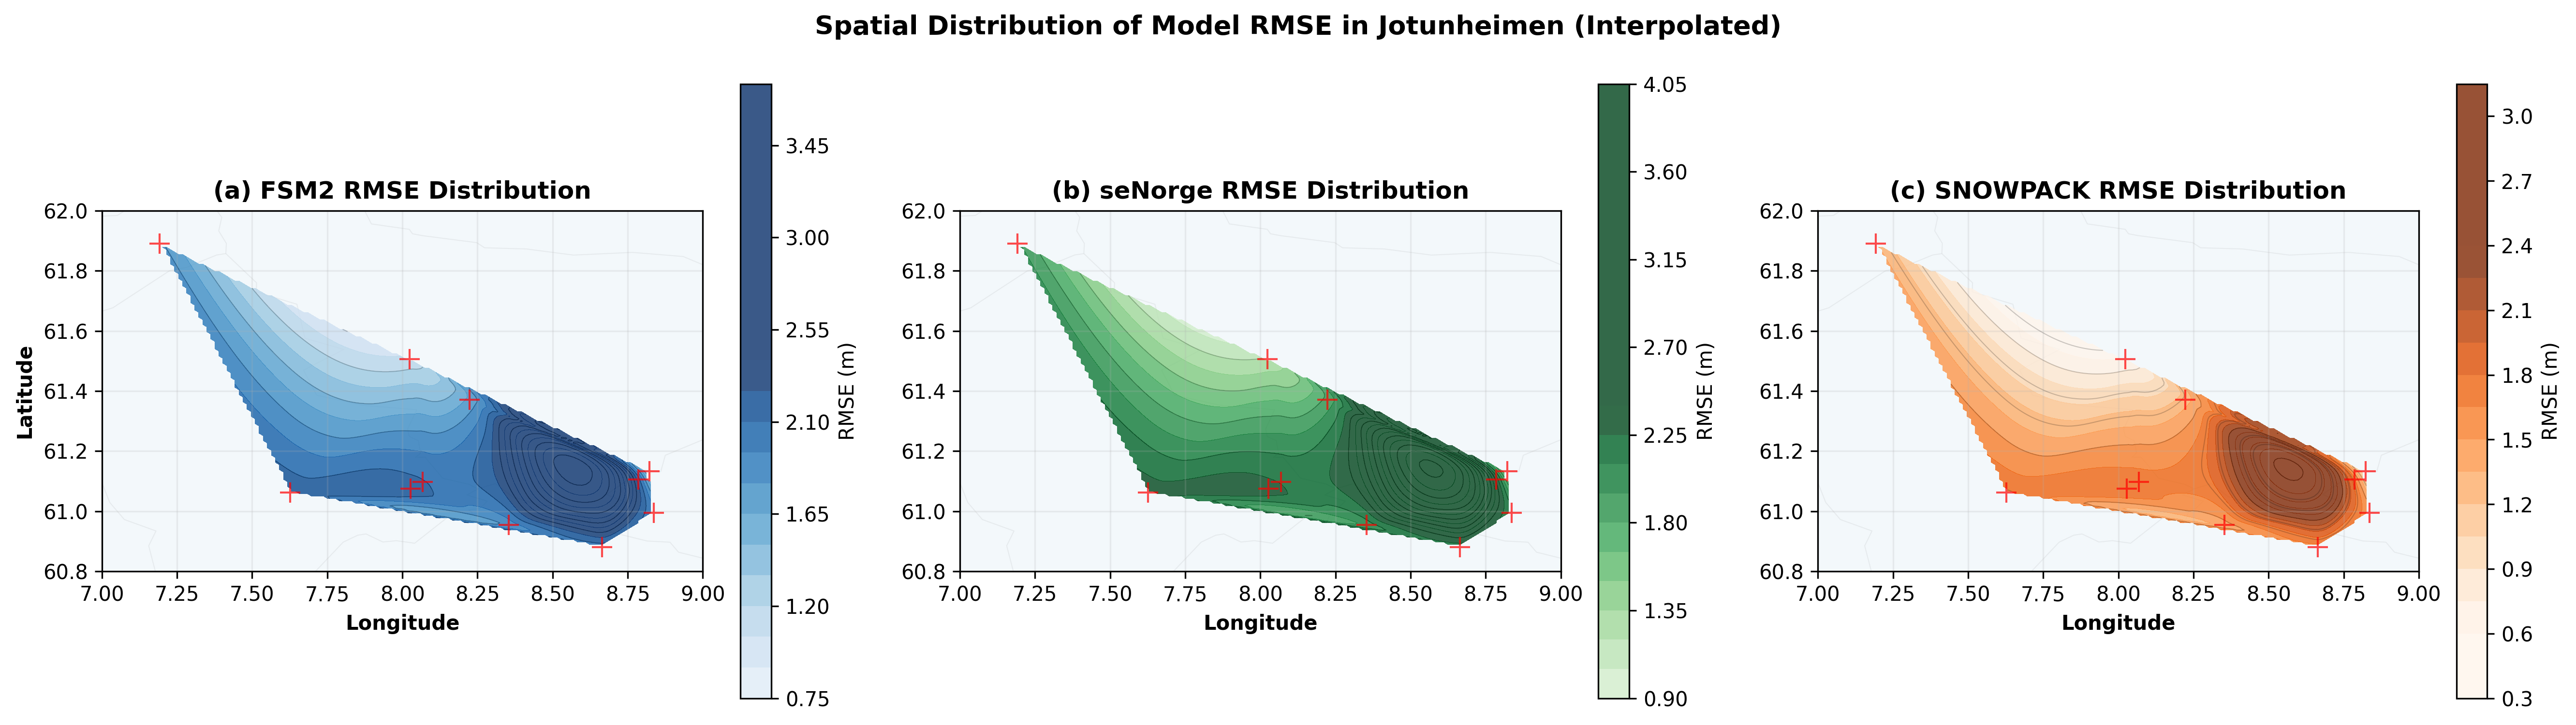

In [6]:
from scipy.interpolate import griddata

# Create grid for interpolation - Jotunheimen area only
rmse_cols_available = [col for col in ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE'] if col in stations_gdf.columns]

# Check we have data
if len(stations_gdf) == 0:
    print("Warning: No stations with coordinates found!")
else:
    # Define Jotunheimen bounds
    jotun_bounds = {'west': 7.0, 'east': 9.0, 'south': 60.8, 'north': 62.0}
    xi = np.linspace(jotun_bounds['west'], jotun_bounds['east'], 150)
    yi = np.linspace(jotun_bounds['south'], jotun_bounds['north'], 150)
    xi, yi = np.meshgrid(xi, yi)

    # Create 3 subplots for interpolated RMSE
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    models = ['FSM2', 'seNorge', 'SNOWPACK']
    rmse_cols = ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE']
    colors_list = ['Blues', 'Greens', 'Oranges']

    for idx, (ax, model, col, cmap) in enumerate(zip(axes, models, rmse_cols, colors_list)):
        if col not in stations_gdf.columns:
            ax.text(0.5, 0.5, f'{model} data\nnot available', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'({"abc"[idx]}) {model}', fontweight='bold')
            ax.axis('off')
            continue
        
        # Check for valid data
        valid_data = stations_gdf[[col]].dropna()
        if len(valid_data) < 3:
            ax.text(0.5, 0.5, f'{model}: not enough\nvalid data points', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'({"abc"[idx]}) {model}', fontweight='bold')
            ax.axis('off')
            continue
        
        # Prepare points for interpolation - only valid points
        valid_mask = stations_gdf[col].notna()
        points = np.array([stations_gdf[valid_mask].geometry.x.values, 
                          stations_gdf[valid_mask].geometry.y.values]).T
        values = stations_gdf[valid_mask][col].values
        
        # Interpolate RMSE values across the grid
        try:
            zi = griddata(points, values, (xi, yi), method='cubic')
        except:
            # Fallback to linear if cubic fails
            zi = griddata(points, values, (xi, yi), method='linear')
        
        # Plot base map
        if regions_gdf is not None:
            regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'],
                                            jotun_bounds['south']:jotun_bounds['north']]
            regions_subset.plot(ax=ax, alpha=0.05, edgecolor='gray', linewidth=0.5)
        
        # Plot interpolated heatmap
        vmin = stations_gdf[rmse_cols_available].min().min()
        vmax = stations_gdf[rmse_cols_available].max().max()
        
        contourf = ax.contourf(xi, yi, zi, levels=20, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.8)
        contours = ax.contour(xi, yi, zi, levels=10, colors='black', alpha=0.2, linewidths=0.5)
        
        # Overlay station points
        ax.scatter(stations_gdf[valid_mask].geometry.x, stations_gdf[valid_mask].geometry.y,
                  c='red', s=100, edgecolors='darkred', linewidth=1, alpha=0.7, marker='+', zorder=5)
        
        # Colorbar
        cbar = plt.colorbar(contourf, ax=ax, label='RMSE (m)')
        
        # Labels and formatting
        ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
        ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
        ax.set_xlabel('Longitude', fontweight='bold')
        if idx == 0:
            ax.set_ylabel('Latitude', fontweight='bold')
        ax.set_title(f'({"abc"[idx]}) {model} RMSE Distribution', fontweight='bold')
        ax.grid(True, alpha=0.2)
        ax.set_aspect('equal')

    plt.suptitle('Spatial Distribution of Model RMSE in Jotunheimen (Interpolated)', fontsize=13, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.savefig('../data/processed/Figure_05_Spatial_RMSE_Distribution.png', dpi=300, bbox_inches='tight')
    print("✓ Figure 5 saved: Figure_05_Spatial_RMSE_Distribution.png")
    plt.show()


## 5c. Zoomed Map: Interpolated RMSE Heatmaps (Jotunheimen)

✓ Zoomed RMSE map saved: Figure_05c_Spatial_RMSE_Jotun_Zoomed.png


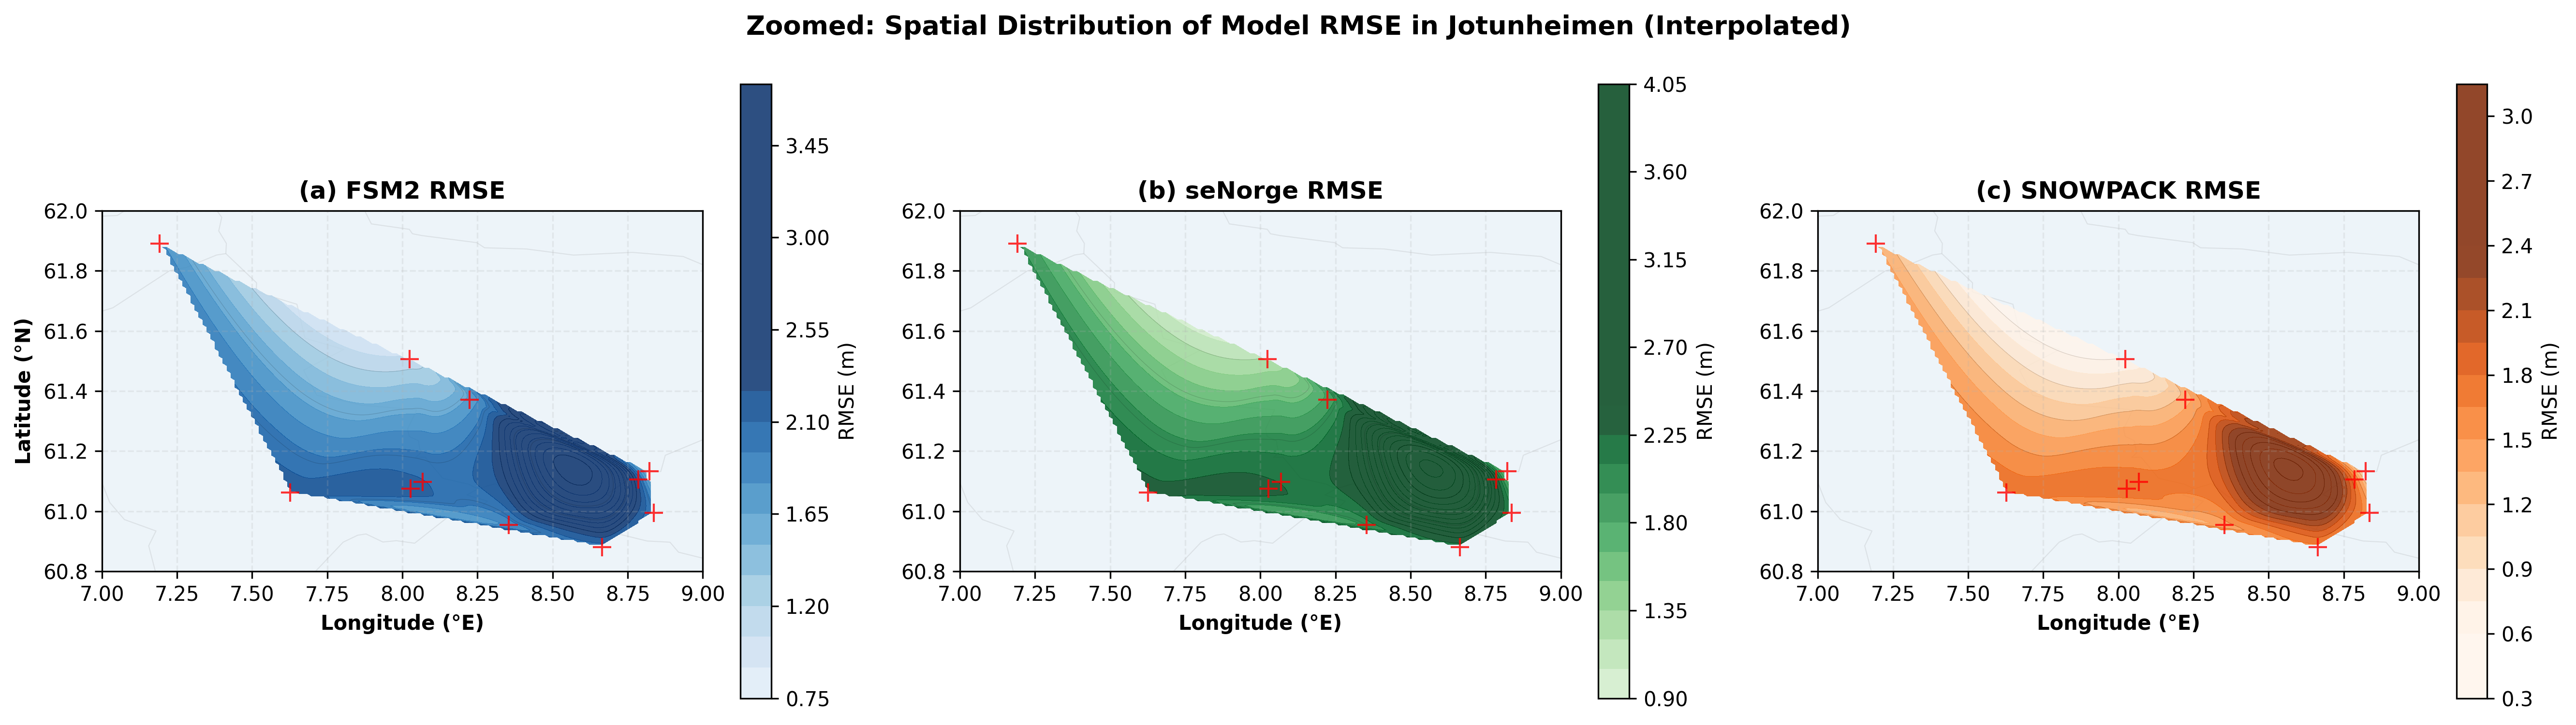

In [7]:
# Zoomed RMSE heatmaps for Jotunheimen
rmse_cols_available = [col for col in ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE'] if col in stations_gdf.columns]

# Define Jotunheimen bounds
jotun_bounds = {'west': 7.0, 'east': 9.0, 'south': 60.8, 'north': 62.0}

# Create grid for interpolation within bounds
xi_zoom = np.linspace(jotun_bounds['west'], jotun_bounds['east'], 150)
yi_zoom = np.linspace(jotun_bounds['south'], jotun_bounds['north'], 150)
xi_zoom, yi_zoom = np.meshgrid(xi_zoom, yi_zoom)

# Prepare points for interpolation
valid_mask = stations_gdf[rmse_cols_available].notna().any(axis=1)
points = np.array([stations_gdf[valid_mask].geometry.x.values, 
                    stations_gdf[valid_mask].geometry.y.values]).T

# Create zoomed subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['FSM2', 'seNorge', 'SNOWPACK']
rmse_cols = ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE']
colors_list = ['Blues', 'Greens', 'Oranges']

for idx, (ax, model, col, cmap) in enumerate(zip(axes, models, rmse_cols, colors_list)):
    if col not in stations_gdf.columns:
        ax.text(0.5, 0.5, f'{model}: not available', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({chr(97+idx)}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Check for valid data
    valid_data = stations_gdf[[col]].dropna()
    if len(valid_data) < 3:
        ax.text(0.5, 0.5, f'{model}: insufficient data', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({chr(97+idx)}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Prepare points for this model
    valid_mask_model = stations_gdf[col].notna()
    points_model = np.array([stations_gdf[valid_mask_model].geometry.x.values,
                            stations_gdf[valid_mask_model].geometry.y.values]).T
    values_model = stations_gdf[valid_mask_model][col].values
    
    # Interpolate
    try:
        zi = griddata(points_model, values_model, (xi_zoom, yi_zoom), method='cubic')
    except:
        zi = griddata(points_model, values_model, (xi_zoom, yi_zoom), method='linear')
    
    # Plot background
    if regions_gdf is not None:
        regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'],
                                        jotun_bounds['south']:jotun_bounds['north']]
        regions_subset.plot(ax=ax, alpha=0.08, edgecolor='gray', linewidth=0.5)
    
    # Plot heatmap
    vmin = min(stations_gdf[c].min() for c in rmse_cols_available if c in stations_gdf.columns)
    vmax = max(stations_gdf[c].max() for c in rmse_cols_available if c in stations_gdf.columns)
    
    contourf = ax.contourf(xi_zoom, yi_zoom, zi, levels=20, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.85)
    ax.contour(xi_zoom, yi_zoom, zi, levels=8, colors='black', alpha=0.15, linewidths=0.3)
    
    # Overlay stations
    ax.scatter(stations_gdf[valid_mask_model].geometry.x, stations_gdf[valid_mask_model].geometry.y,
              c='red', s=80, edgecolors='darkred', linewidth=1, alpha=0.8, marker='+', zorder=5)
    
    # Colorbar
    cbar = plt.colorbar(contourf, ax=ax, label='RMSE (m)')
    
    # Format
    ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
    ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
    ax.set_xlabel('Longitude (°E)', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Latitude (°N)', fontweight='bold')
    ax.set_title(f'({chr(97+idx)}) {model} RMSE', fontweight='bold')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_aspect('equal')

plt.suptitle('Zoomed: Spatial Distribution of Model RMSE in Jotunheimen (Interpolated)', 
            fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('../data/processed/Figure_05c_Spatial_RMSE_Jotun_Zoomed.png', dpi=300, bbox_inches='tight')
print("✓ Zoomed RMSE map saved: Figure_05c_Spatial_RMSE_Jotun_Zoomed.png")
plt.show()


## 6. Map 2: Model Bias Distribution

## 6. Direct Model Comparison: Box Plots & Statistics

## 5b. Zoomed Map: Jotunheimen Study Area with Station Locations

✓ Zoomed map saved: Figure_04_Jotunheimen_Stations_Zoomed.png


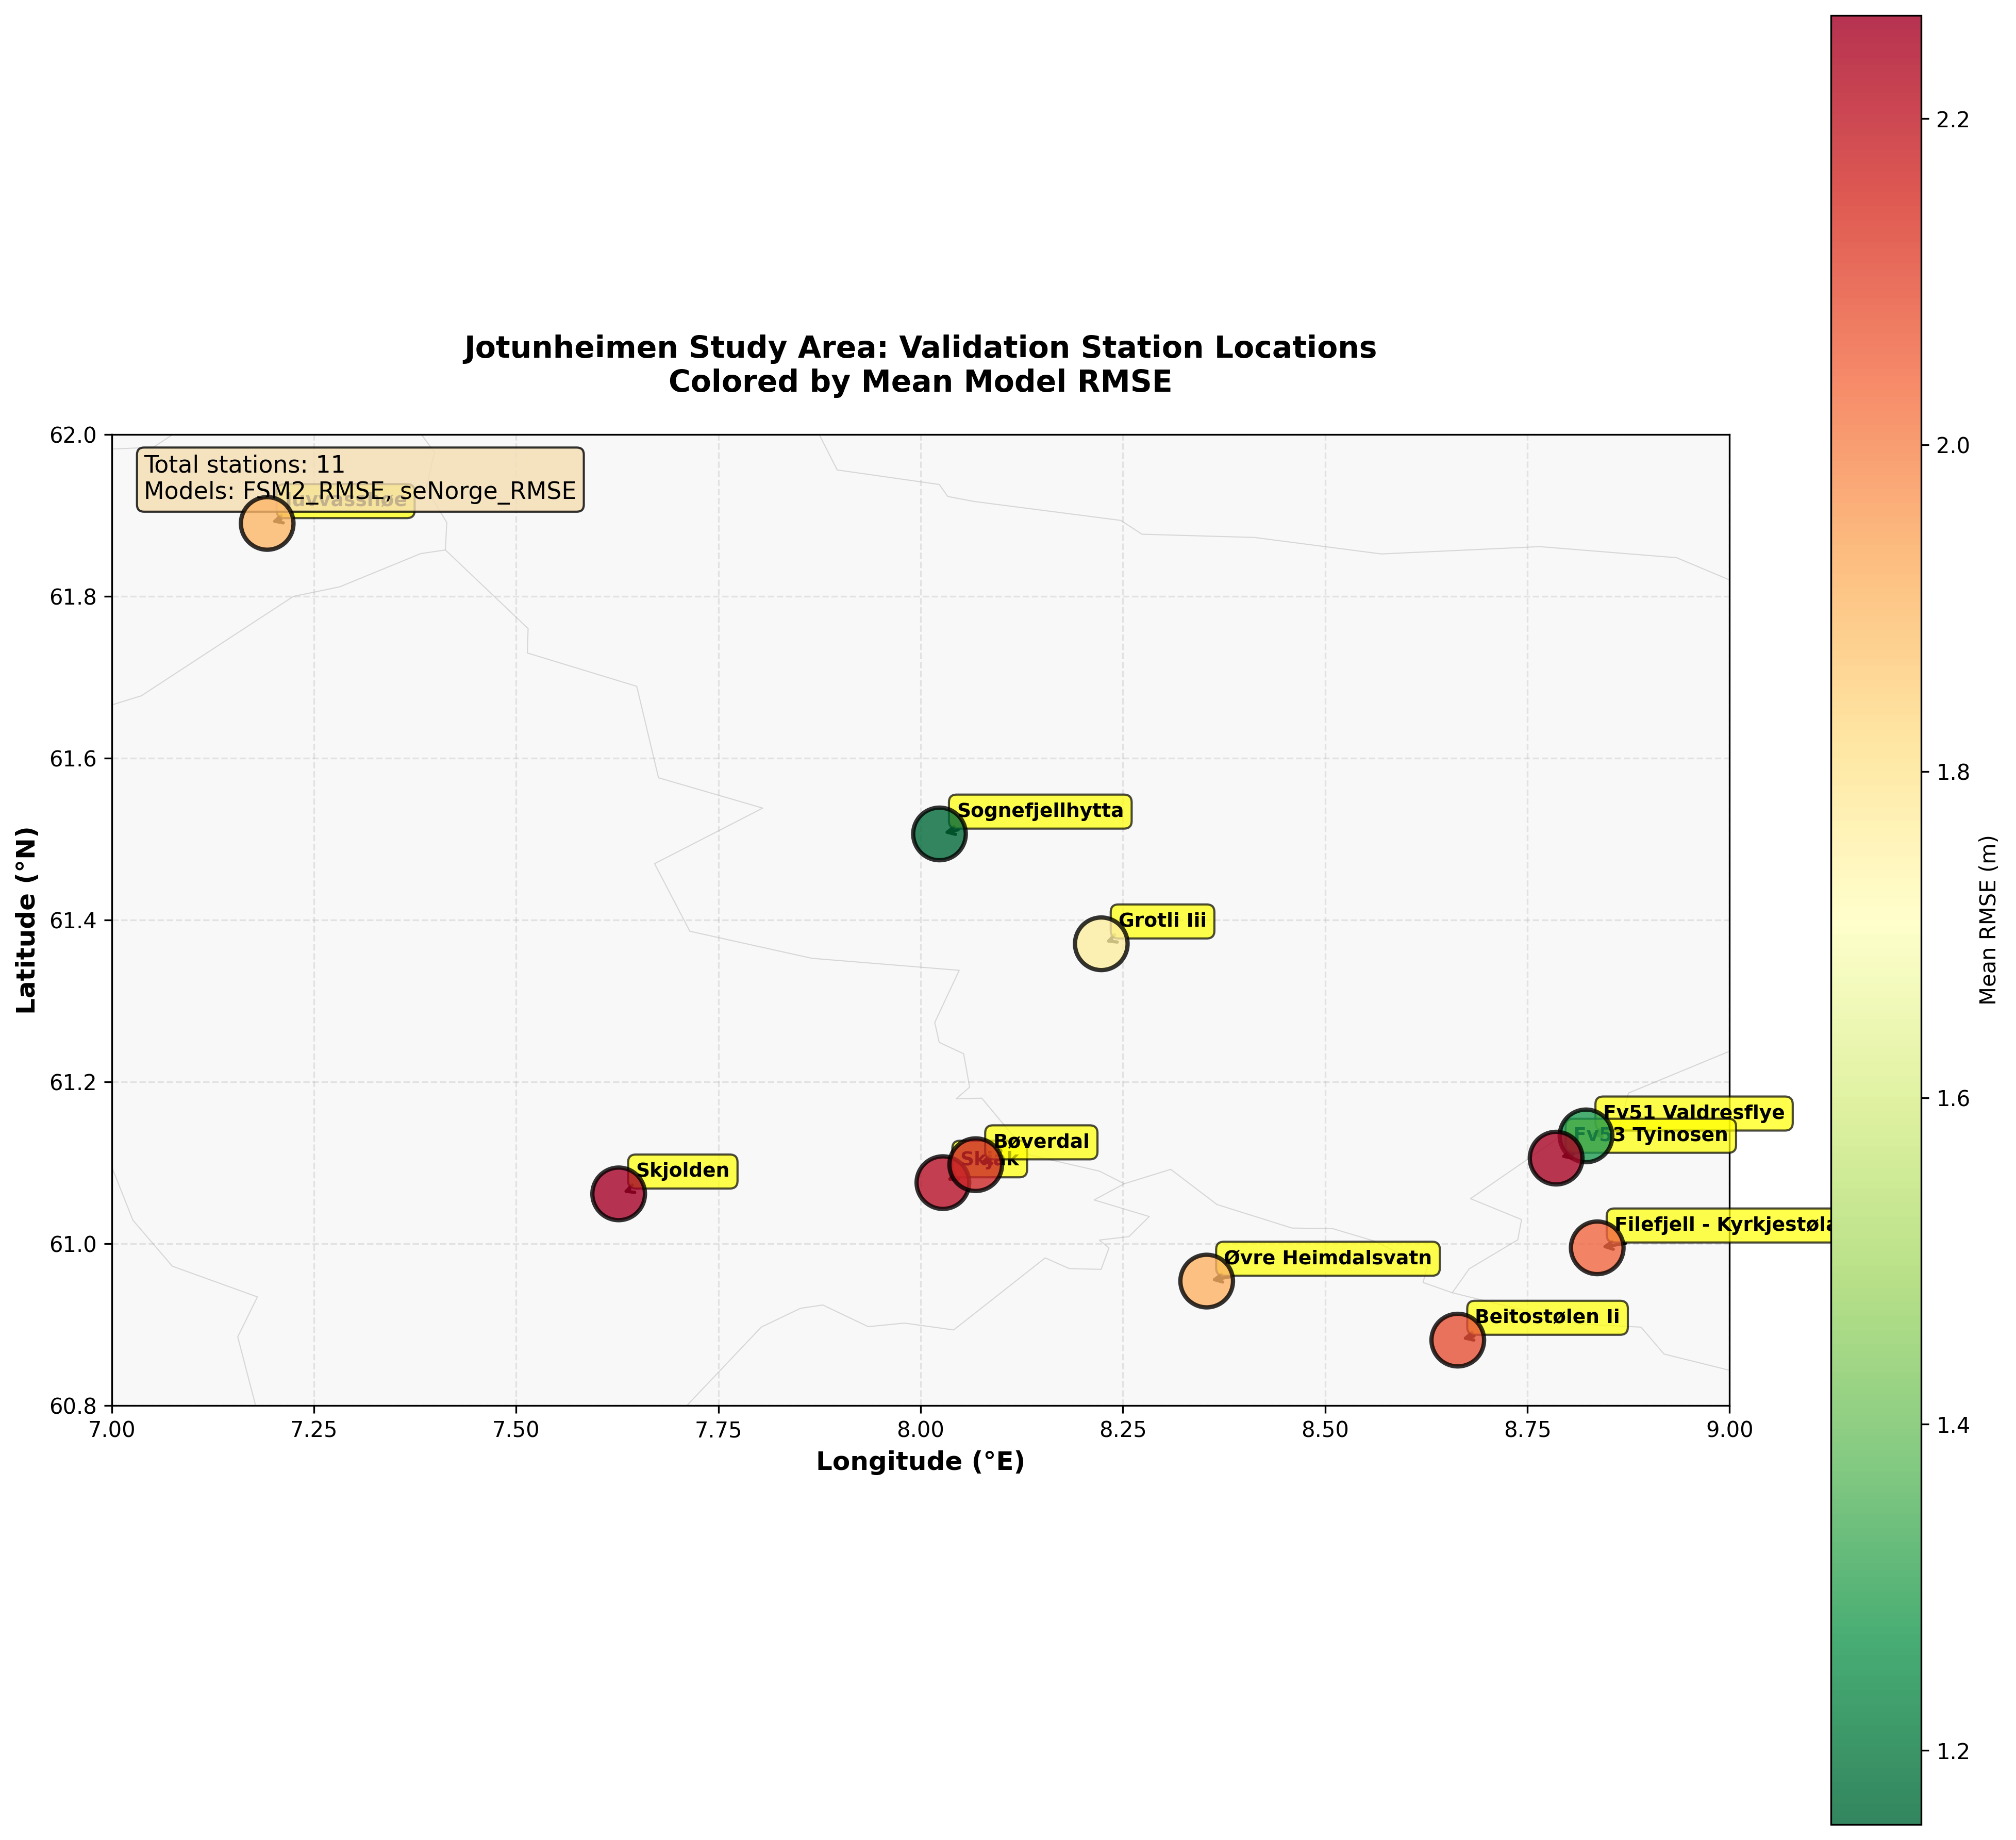

In [8]:
# Create a zoomed map of Jotunheimen region with station locations
fig, ax = plt.subplots(figsize=(14, 12))

# Define Jotunheimen area bounds (with some buffer)
jotun_bounds = {
    'west': 7.0,
    'east': 9.0,
    'south': 60.8,
    'north': 62.0
}

# Plot regional boundaries if available
if regions_gdf is not None:
    # Filter to regions in the area
    regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'], 
                                     jotun_bounds['south']:jotun_bounds['north']]
    regions_subset.plot(ax=ax, alpha=0.15, edgecolor='gray', linewidth=0.5, color='lightgray')

# Plot pixels if available
if pixels_gdf is not None:
    try:
        pixels_subset = pixels_gdf.cx[jotun_bounds['west']:jotun_bounds['east'], 
                                       jotun_bounds['south']:jotun_bounds['north']]
        pixels_subset.plot(ax=ax, alpha=0.05, edgecolor='lightgray', linewidth=0.2, color='gray')
    except:
        pass

# Plot stations with RMSE coloring
rmse_cols_available = [col for col in ['FSM2_RMSE', 'seNorge_RMSE'] if col in stations_gdf.columns]

if len(rmse_cols_available) > 0:
    # Calculate mean RMSE for color coding
    stations_gdf['mean_RMSE'] = stations_gdf[rmse_cols_available].mean(axis=1)
    
    # Plot stations with size based on RMSE
    vmin = stations_gdf['mean_RMSE'].min()
    vmax = stations_gdf['mean_RMSE'].max()
    
    sc = ax.scatter(stations_gdf.geometry.x, stations_gdf.geometry.y,
                   c=stations_gdf['mean_RMSE'], s=600, cmap='RdYlGn_r',
                   vmin=vmin, vmax=vmax, edgecolors='black', linewidth=2, alpha=0.8, zorder=5)
    
    cbar = plt.colorbar(sc, ax=ax, label='Mean RMSE (m)')

# Add station labels
for idx, row in stations_gdf.iterrows():
    ax.annotate(row['Station'], 
               xy=(row.geometry.x, row.geometry.y),
               xytext=(8, 8),
               textcoords='offset points',
               fontsize=9,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black', lw=1.5))

# Set the extent to Jotunheimen area
ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])

# Formatting
ax.set_xlabel('Longitude (°E)', fontweight='bold', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontweight='bold', fontsize=12)
ax.set_title('Jotunheimen Study Area: Validation Station Locations\nColored by Mean Model RMSE', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_aspect('equal')

# Add some context text
ax.text(0.02, 0.98, f'Total stations: {len(stations_gdf)}\nModels: {", ".join(rmse_cols_available)}',
       transform=ax.transAxes, fontsize=11, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../data/processed/Figure_04_Jotunheimen_Stations_Zoomed.png', dpi=300, bbox_inches='tight')
print("✓ Zoomed map saved: Figure_04_Jotunheimen_Stations_Zoomed.png")
plt.show()


Available RMSE columns: ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE']
Total stations: 11
  FSM2: 11 valid values
  seNorge: 11 valid values
  SNOWPACK: 11 valid values
Total data points collected: 33
Created comparison DataFrame with 33 data points
Columns: ['Model', 'RMSE (m)']
Models: <StringArray>
['FSM2', 'seNorge', 'SNOWPACK']
Length: 3, dtype: str
✓ Comparison figure saved: Figure_05b_Model_Comparison_Stats.png


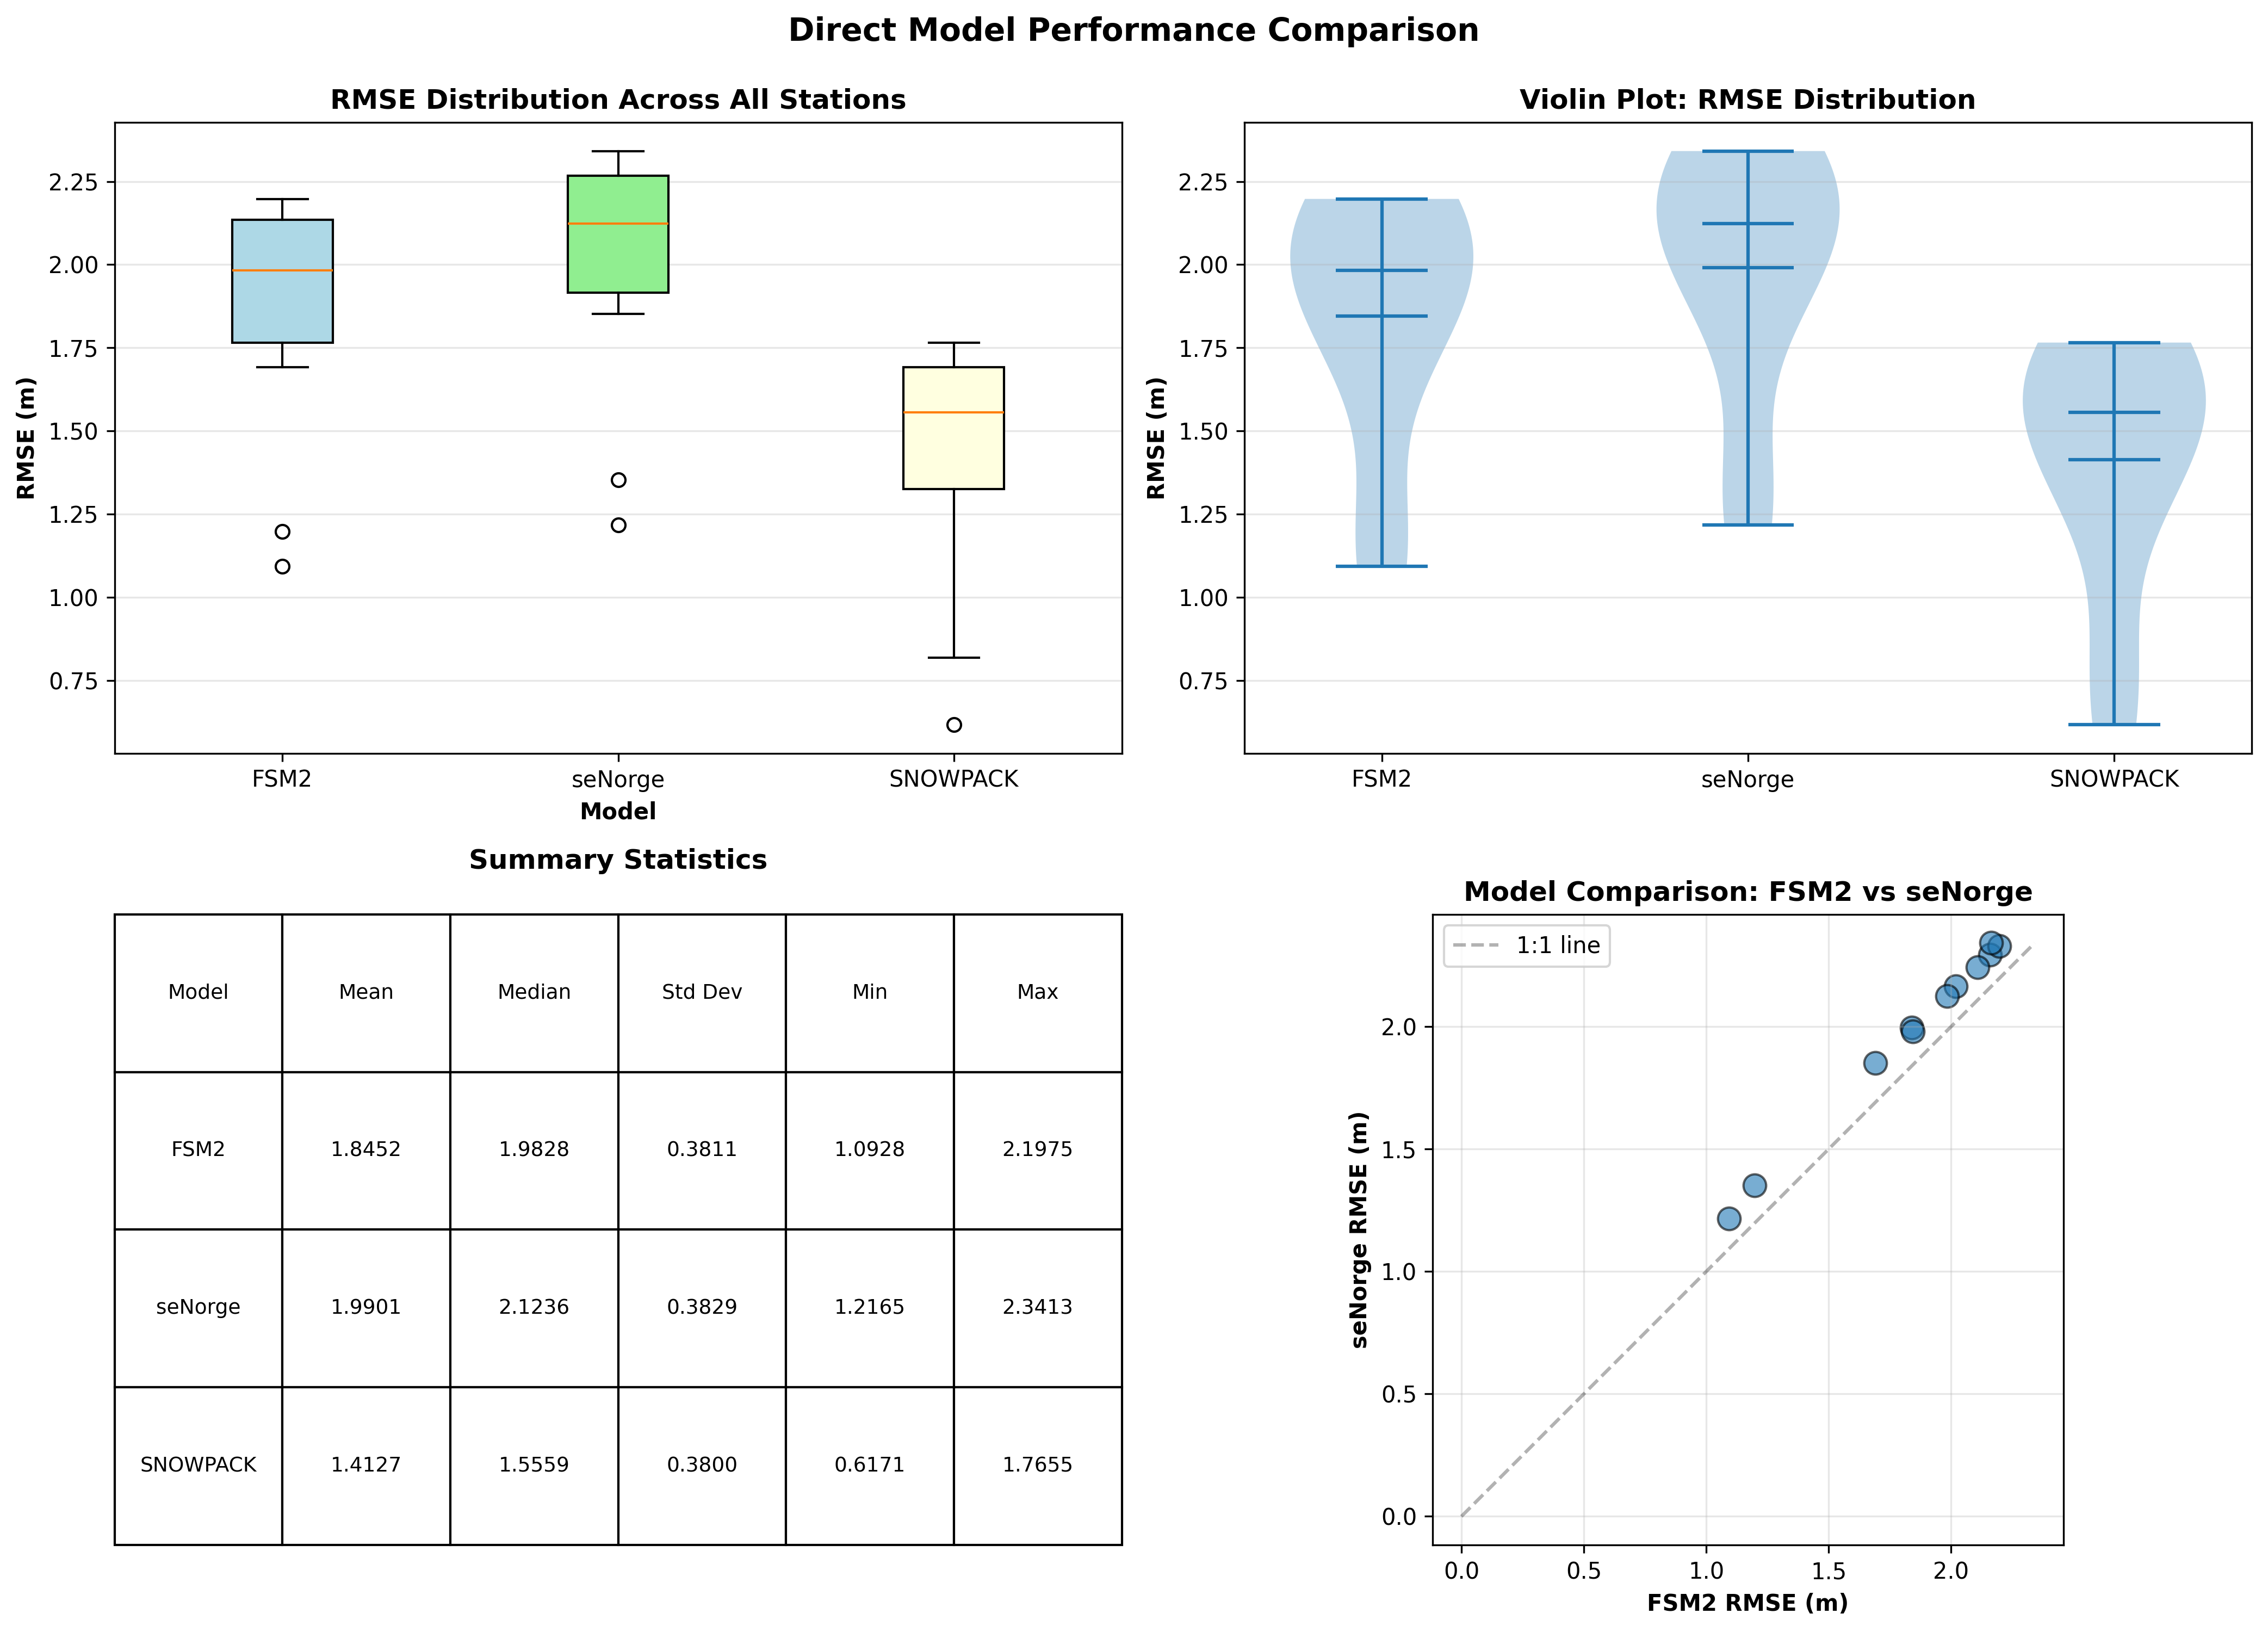

In [9]:
# Prepare data for direct model comparison
rmse_cols_available = [col for col in ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE'] if col in stations_gdf.columns]

print(f"Available RMSE columns: {rmse_cols_available}")
print(f"Total stations: {len(stations_gdf)}")

# Skip if no models available
if len(rmse_cols_available) == 0:
    print("No RMSE data available for comparison")
else:
    rmse_data = []
    for col in rmse_cols_available:
        model_name = col.replace('_RMSE', '')
        # Only use non-NaN values
        valid_vals = stations_gdf[col].dropna().values
        print(f"  {model_name}: {len(valid_vals)} valid values")
        for val in valid_vals:
            rmse_data.append({'Model': model_name, 'RMSE (m)': val})

    print(f"Total data points collected: {len(rmse_data)}")
    
    if len(rmse_data) == 0:
        print("ERROR: No valid data found in any RMSE column")
        print("First few rows of stations_gdf:")
        print(stations_gdf[[col for col in rmse_cols_available]].head(10))
    else:
        rmse_df = pd.DataFrame(rmse_data)
        print(f"Created comparison DataFrame with {len(rmse_df)} data points")
        print(f"Columns: {rmse_df.columns.tolist()}")
        print(f"Models: {rmse_df['Model'].unique()}")

        # Create comprehensive comparison figure
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Box plot using matplotlib
        ax = axes[0, 0]
        models_list = rmse_df['Model'].unique()
        box_data = [rmse_df[rmse_df['Model'] == m]['RMSE (m)'].values for m in models_list]
        bp = ax.boxplot(box_data, labels=models_list, patch_artist=True)
        
        # Color the boxes
        colors = ['lightblue', 'lightgreen', 'lightyellow']
        for patch, color in zip(bp['boxes'], colors[:len(models_list)]):
            patch.set_facecolor(color)
        
        ax.set_title('RMSE Distribution Across All Stations', fontweight='bold')
        ax.set_ylabel('RMSE (m)', fontweight='bold')
        ax.set_xlabel('Model', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Violin plot
        ax = axes[0, 1]
        parts = ax.violinplot([rmse_df[rmse_df['Model'] == m]['RMSE (m)'].values for m in models_list],
                               positions=range(len(models_list)), showmeans=True, showmedians=True)
        ax.set_xticks(range(len(models_list)))
        ax.set_xticklabels(models_list)
        ax.set_ylabel('RMSE (m)', fontweight='bold')
        ax.set_title('Violin Plot: RMSE Distribution', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Statistics table
        ax = axes[1, 0]
        ax.axis('off')
        stats_data = []
        for model in models_list:
            model_data = rmse_df[rmse_df['Model'] == model]['RMSE (m)']
            stats_data.append([
                model,
                f"{model_data.mean():.4f}",
                f"{model_data.median():.4f}",
                f"{model_data.std():.4f}",
                f"{model_data.min():.4f}",
                f"{model_data.max():.4f}"
            ])

        table = ax.table(cellText=stats_data,
                        colLabels=['Model', 'Mean', 'Median', 'Std Dev', 'Min', 'Max'],
                        cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.8)
        ax.set_title('Summary Statistics', pad=20, fontweight='bold')

        # Scatter plot: RMSE of model pairs
        ax = axes[1, 1]
        if len(rmse_cols_available) >= 2:
            col1, col2 = rmse_cols_available[0], rmse_cols_available[1]
            m1, m2 = col1.replace('_RMSE', ''), col2.replace('_RMSE', '')
            
            # Only plot where both have data
            mask = stations_gdf[[col1, col2]].notna().all(axis=1)
            if mask.sum() > 0:
                ax.scatter(stations_gdf[mask][col1], stations_gdf[mask][col2], alpha=0.6, s=100, edgecolors='black', linewidth=1)
                
                # Add diagonal line
                max_val = max(stations_gdf[col1].max(), stations_gdf[col2].max())
                ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='1:1 line')
                
                ax.set_xlabel(f'{m1} RMSE (m)', fontweight='bold')
                ax.set_ylabel(f'{m2} RMSE (m)', fontweight='bold')
                ax.set_title(f'Model Comparison: {m1} vs {m2}', fontweight='bold')
                ax.legend()
                ax.grid(True, alpha=0.3)
                ax.set_aspect('equal')
            else:
                ax.text(0.5, 0.5, f'No overlapping data\nbetween {m1} and {m2}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Need at least 2 models\nfor comparison', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')

        plt.suptitle('Direct Model Performance Comparison', fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.savefig('../data/processed/Figure_05b_Model_Comparison_Stats.png', dpi=300, bbox_inches='tight')
        print("✓ Comparison figure saved: Figure_05b_Model_Comparison_Stats.png")
        plt.show()


✓ Figure 6 saved: Figure_06_Spatial_Bias_Distribution.png


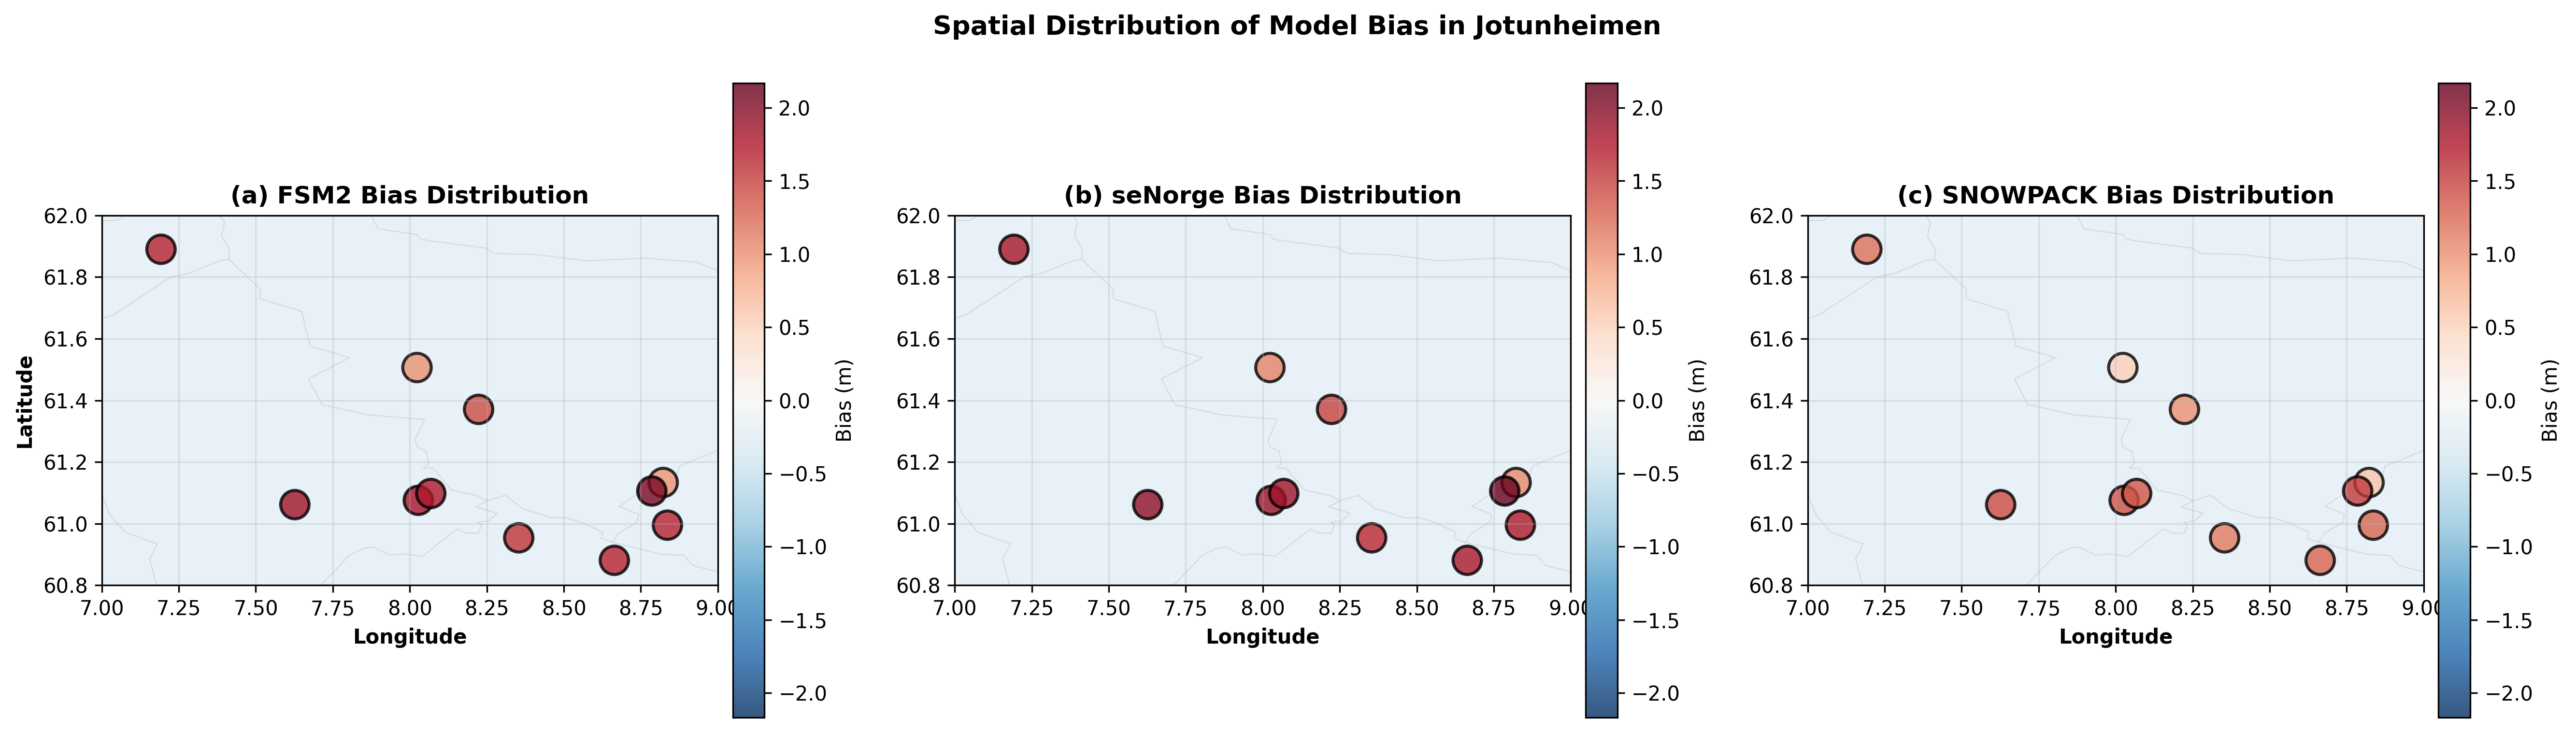

In [10]:
# Create 3 subplots for Bias - Jotunheimen area
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define Jotunheimen bounds
jotun_bounds = {'west': 7.0, 'east': 9.0, 'south': 60.8, 'north': 62.0}

bias_cols = ['FSM2_Bias', 'seNorge_Bias', 'SNOWPACK_Bias']
cmap_diverging = 'RdBu_r'  # Red-Blue diverging colormap

# Filter to only include columns that exist
bias_cols_available = [col for col in bias_cols if col in stations_gdf.columns]

for idx, (ax, model, col) in enumerate(zip(axes, models, bias_cols)):
    # Check if column exists
    if col not in stations_gdf.columns:
        ax.text(0.5, 0.5, f'{model} data\nnot available', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({"abc"[idx]}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Plot base map - Jotunheimen only
    if regions_gdf is not None:
        regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'],
                                        jotun_bounds['south']:jotun_bounds['north']]
        regions_subset.plot(ax=ax, alpha=0.1, edgecolor='gray', linewidth=0.5)
    
    # Use symmetric colormap (diverging around 0)
    vmax_abs = abs(stations_gdf[bias_cols_available]).max().max()
    
    sc = ax.scatter(stations_gdf.geometry.x, stations_gdf.geometry.y,
                   c=stations_gdf[col], s=200, cmap=cmap_diverging,
                   vmin=-vmax_abs, vmax=vmax_abs, edgecolors='black', linewidth=1.5,
                   alpha=0.8)
    
    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, label='Bias (m)', pad=0.02)
    
    # Labels and formatting
    ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
    ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
    ax.set_xlabel('Longitude', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Latitude', fontweight='bold')
    ax.set_title(f'({"abc"[idx]}) {model} Bias Distribution', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Spatial Distribution of Model Bias in Jotunheimen', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/processed/Figure_06_Spatial_Bias_Distribution.png', dpi=300, bbox_inches='tight')
print("✓ Figure 6 saved: Figure_06_Spatial_Bias_Distribution.png")
plt.show()


## 6b. Zoomed Map: Model Bias Distribution (Jotunheimen)

✓ Zoomed Bias map saved: Figure_06b_Spatial_Bias_Jotun_Zoomed.png


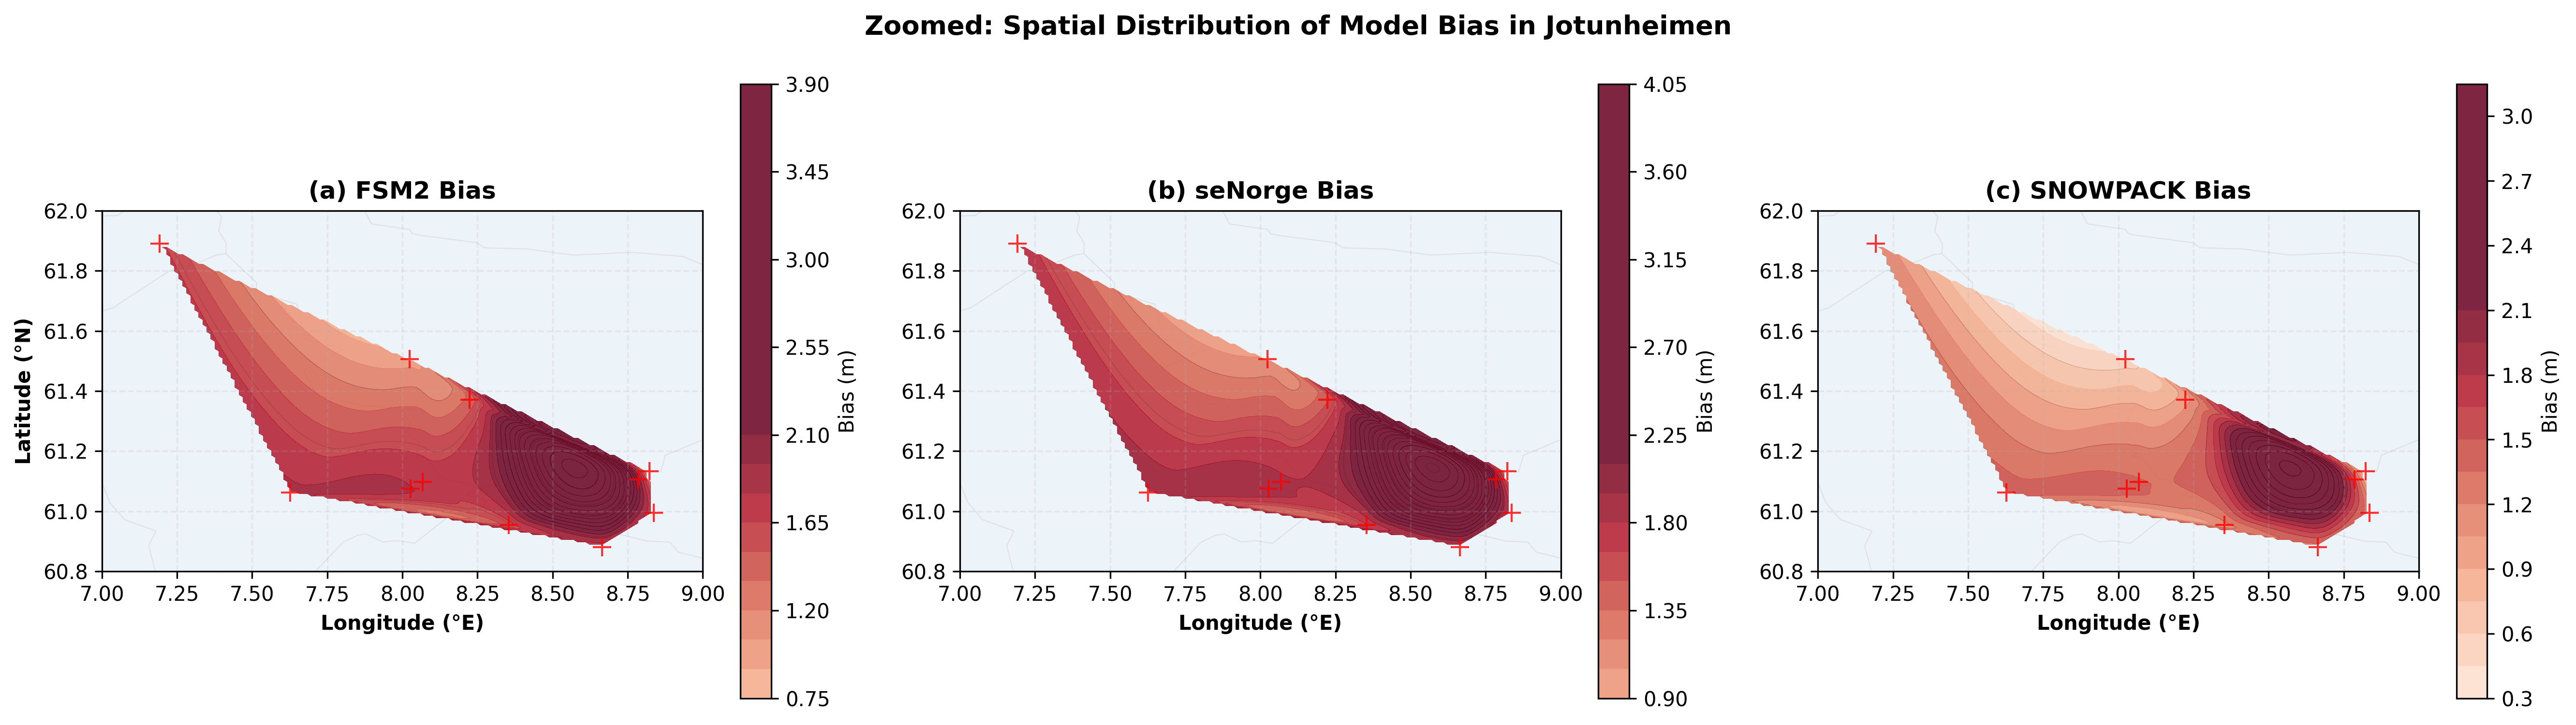

In [11]:
# Zoomed Bias heatmaps for Jotunheimen
bias_cols = ['FSM2_Bias', 'seNorge_Bias', 'SNOWPACK_Bias']
bias_cols_available = [col for col in bias_cols if col in stations_gdf.columns]

# Define Jotunheimen bounds
jotun_bounds = {'west': 7.0, 'east': 9.0, 'south': 60.8, 'north': 62.0}

# Create grid
xi_zoom = np.linspace(jotun_bounds['west'], jotun_bounds['east'], 150)
yi_zoom = np.linspace(jotun_bounds['south'], jotun_bounds['north'], 150)
xi_zoom, yi_zoom = np.meshgrid(xi_zoom, yi_zoom)

# Create zoomed subplots for bias
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['FSM2', 'seNorge', 'SNOWPACK']
bias_cols_plot = ['FSM2_Bias', 'seNorge_Bias', 'SNOWPACK_Bias']
cmap_diverging = 'RdBu_r'

for idx, (ax, model, col) in enumerate(zip(axes, models, bias_cols_plot)):
    if col not in stations_gdf.columns:
        ax.text(0.5, 0.5, f'{model}: not available', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({chr(97+idx)}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Check for valid data
    valid_data = stations_gdf[[col]].dropna()
    if len(valid_data) < 3:
        ax.text(0.5, 0.5, f'{model}: insufficient data', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({chr(97+idx)}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Prepare points for this model
    valid_mask_model = stations_gdf[col].notna()
    points_model = np.array([stations_gdf[valid_mask_model].geometry.x.values,
                            stations_gdf[valid_mask_model].geometry.y.values]).T
    values_model = stations_gdf[valid_mask_model][col].values
    
    # Interpolate
    try:
        zi = griddata(points_model, values_model, (xi_zoom, yi_zoom), method='cubic')
    except:
        zi = griddata(points_model, values_model, (xi_zoom, yi_zoom), method='linear')
    
    # Plot background
    if regions_gdf is not None:
        regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'],
                                        jotun_bounds['south']:jotun_bounds['north']]
        regions_subset.plot(ax=ax, alpha=0.08, edgecolor='gray', linewidth=0.5)
    
    # Plot heatmap with symmetric colormap
    vmax_abs = max(abs(stations_gdf[c].min()) for c in bias_cols_available 
                   if c in stations_gdf.columns)
    vmax_abs = max(vmax_abs, max(stations_gdf[c].max() for c in bias_cols_available 
                                 if c in stations_gdf.columns))
    
    contourf = ax.contourf(xi_zoom, yi_zoom, zi, levels=20, cmap=cmap_diverging, 
                          vmin=-vmax_abs, vmax=vmax_abs, alpha=0.85)
    ax.contour(xi_zoom, yi_zoom, zi, levels=8, colors='black', alpha=0.15, linewidths=0.3)
    
    # Overlay stations
    ax.scatter(stations_gdf[valid_mask_model].geometry.x, stations_gdf[valid_mask_model].geometry.y,
              c='red', s=80, edgecolors='darkred', linewidth=1, alpha=0.8, marker='+', zorder=5)
    
    # Colorbar
    cbar = plt.colorbar(contourf, ax=ax, label='Bias (m)')
    
    # Format
    ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
    ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
    ax.set_xlabel('Longitude (°E)', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Latitude (°N)', fontweight='bold')
    ax.set_title(f'({chr(97+idx)}) {model} Bias', fontweight='bold')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_aspect('equal')

plt.suptitle('Zoomed: Spatial Distribution of Model Bias in Jotunheimen', 
            fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('../data/processed/Figure_06b_Spatial_Bias_Jotun_Zoomed.png', dpi=300, bbox_inches='tight')
print("✓ Zoomed Bias map saved: Figure_06b_Spatial_Bias_Jotun_Zoomed.png")
plt.show()


## 7. Map 3: Model Correlation Distribution

✓ Figure 7 saved: Figure_07_Spatial_Correlation_Distribution.png


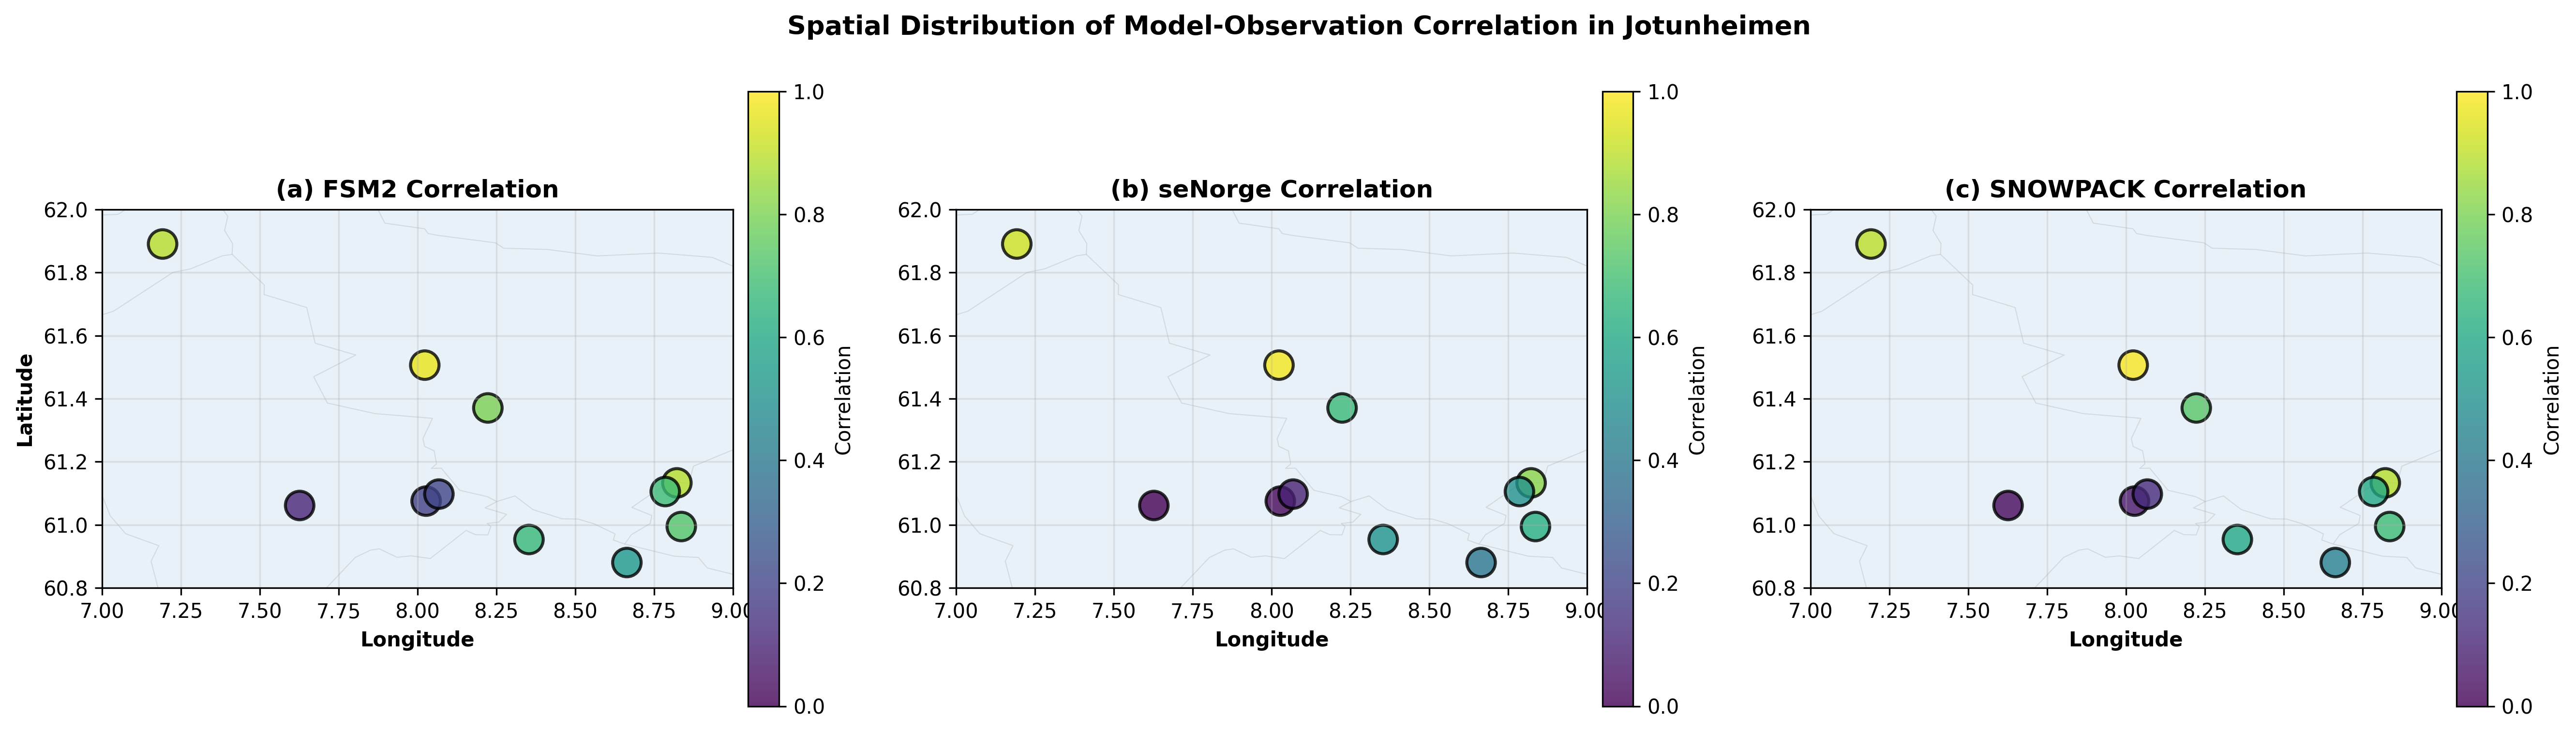

In [12]:
# Create 3 subplots for Correlation - Jotunheimen area
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define Jotunheimen bounds
jotun_bounds = {'west': 7.0, 'east': 9.0, 'south': 60.8, 'north': 62.0}

correlation_cols = ['FSM2_Corr', 'seNorge_Corr', 'SNOWPACK_Corr']
cmap_sequential = 'viridis'  # Viridis for 0-1 range

# Filter to only include columns that exist
correlation_cols_available = [col for col in correlation_cols if col in stations_gdf.columns]

for idx, (ax, model, col) in enumerate(zip(axes, models, correlation_cols)):
    # Check if column exists
    if col not in stations_gdf.columns:
        ax.text(0.5, 0.5, f'{model} data\nnot available', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({"abc"[idx]}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Plot base map - Jotunheimen only
    if regions_gdf is not None:
        regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'],
                                        jotun_bounds['south']:jotun_bounds['north']]
        regions_subset.plot(ax=ax, alpha=0.1, edgecolor='gray', linewidth=0.5)
    
    # Scatter plot with viridis colormap (0-1 range)
    sc = ax.scatter(stations_gdf.geometry.x, stations_gdf.geometry.y,
                   c=stations_gdf[col], s=200, cmap=cmap_sequential,
                   vmin=0, vmax=1, edgecolors='black', linewidth=1.5,
                   alpha=0.8)
    
    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, label='Correlation', pad=0.02)
    
    # Labels and formatting
    ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
    ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
    ax.set_xlabel('Longitude', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Latitude', fontweight='bold')
    ax.set_title(f'({"abc"[idx]}) {model} Correlation', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Spatial Distribution of Model-Observation Correlation in Jotunheimen', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/processed/Figure_07_Spatial_Correlation_Distribution.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7 saved: Figure_07_Spatial_Correlation_Distribution.png")
plt.show()


## 7b. Zoomed Map: Model Correlation Distribution (Jotunheimen)

✓ Zoomed Correlation map saved: Figure_07b_Spatial_Correlation_Jotun_Zoomed.png


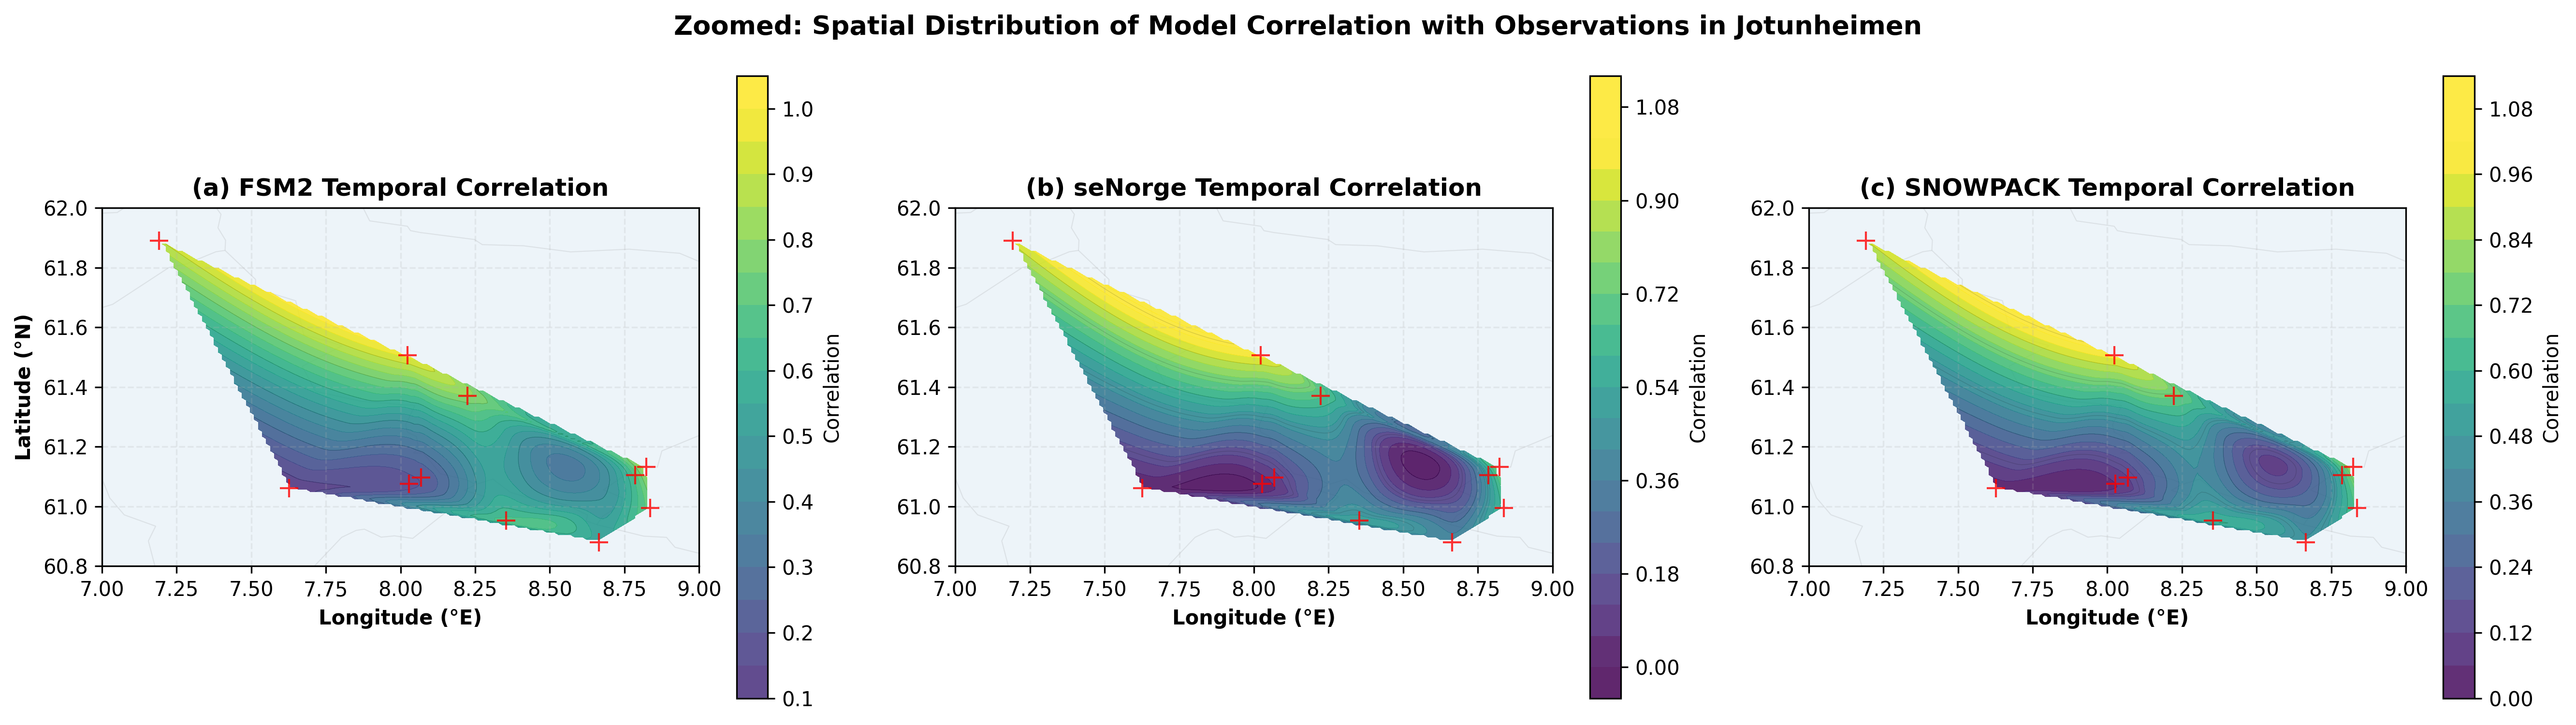

In [13]:
# Zoomed Correlation heatmaps for Jotunheimen
corr_cols = ['FSM2_Corr', 'seNorge_Corr', 'SNOWPACK_Corr']
corr_cols_available = [col for col in corr_cols if col in stations_gdf.columns]

# Define Jotunheimen bounds
jotun_bounds = {'west': 7.0, 'east': 9.0, 'south': 60.8, 'north': 62.0}

# Create grid
xi_zoom = np.linspace(jotun_bounds['west'], jotun_bounds['east'], 150)
yi_zoom = np.linspace(jotun_bounds['south'], jotun_bounds['north'], 150)
xi_zoom, yi_zoom = np.meshgrid(xi_zoom, yi_zoom)

# Create zoomed subplots for correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['FSM2', 'seNorge', 'SNOWPACK']
corr_cols_plot = ['FSM2_Corr', 'seNorge_Corr', 'SNOWPACK_Corr']

for idx, (ax, model, col) in enumerate(zip(axes, models, corr_cols_plot)):
    if col not in stations_gdf.columns:
        ax.text(0.5, 0.5, f'{model}: not available', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({chr(97+idx)}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Check for valid data
    valid_data = stations_gdf[[col]].dropna()
    if len(valid_data) < 3:
        ax.text(0.5, 0.5, f'{model}: insufficient data', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'({chr(97+idx)}) {model}', fontweight='bold')
        ax.axis('off')
        continue
    
    # Prepare points for this model
    valid_mask_model = stations_gdf[col].notna()
    points_model = np.array([stations_gdf[valid_mask_model].geometry.x.values,
                            stations_gdf[valid_mask_model].geometry.y.values]).T
    values_model = stations_gdf[valid_mask_model][col].values
    
    # Interpolate
    try:
        zi = griddata(points_model, values_model, (xi_zoom, yi_zoom), method='cubic')
    except:
        zi = griddata(points_model, values_model, (xi_zoom, yi_zoom), method='linear')
    
    # Plot background
    if regions_gdf is not None:
        regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'],
                                        jotun_bounds['south']:jotun_bounds['north']]
        regions_subset.plot(ax=ax, alpha=0.08, edgecolor='gray', linewidth=0.5)
    
    # Plot heatmap
    contourf = ax.contourf(xi_zoom, yi_zoom, zi, levels=20, cmap='viridis', 
                          vmin=0, vmax=1, alpha=0.85)
    ax.contour(xi_zoom, yi_zoom, zi, levels=8, colors='black', alpha=0.15, linewidths=0.3)
    
    # Overlay stations
    ax.scatter(stations_gdf[valid_mask_model].geometry.x, stations_gdf[valid_mask_model].geometry.y,
              c='red', s=80, edgecolors='darkred', linewidth=1, alpha=0.8, marker='+', zorder=5)
    
    # Colorbar
    cbar = plt.colorbar(contourf, ax=ax, label='Correlation')
    
    # Format
    ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
    ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
    ax.set_xlabel('Longitude (°E)', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Latitude (°N)', fontweight='bold')
    ax.set_title(f'({chr(97+idx)}) {model} Temporal Correlation', fontweight='bold')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_aspect('equal')

plt.suptitle('Zoomed: Spatial Distribution of Model Correlation with Observations in Jotunheimen', 
            fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('../data/processed/Figure_07b_Spatial_Correlation_Jotun_Zoomed.png', dpi=300, bbox_inches='tight')
print("✓ Zoomed Correlation map saved: Figure_07b_Spatial_Correlation_Jotun_Zoomed.png")
plt.show()


## 8. Map 4: Best vs Worst Performing Model

In [14]:
# Determine best model (lowest RMSE) at each station
# Only use columns that actually exist
rmse_cols_available = [col for col in ['FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE'] if col in stations_gdf.columns]

if len(rmse_cols_available) > 0:
    stations_gdf['best_model'] = stations_gdf[rmse_cols_available].idxmin(axis=1)
    stations_gdf['worst_model'] = stations_gdf[rmse_cols_available].idxmax(axis=1)
    stations_gdf['min_rmse'] = stations_gdf[rmse_cols_available].min(axis=1)
    stations_gdf['max_rmse'] = stations_gdf[rmse_cols_available].max(axis=1)

    # Map model names
    model_map = {'FSM2_RMSE': 'FSM2', 'seNorge_RMSE': 'seNorge', 'SNOWPACK_RMSE': 'SNOWPACK'}
    stations_gdf['best_model_name'] = stations_gdf['best_model'].map(model_map)
    stations_gdf['worst_model_name'] = stations_gdf['worst_model'].map(model_map)

    print("Best model distribution:")
    print(stations_gdf['best_model_name'].value_counts())
    print("\nWorst model distribution:")
    print(stations_gdf['worst_model_name'].value_counts())
else:
    print("Warning: No RMSE columns found in data!")


Best model distribution:
best_model_name
SNOWPACK    11
Name: count, dtype: int64

Worst model distribution:
worst_model_name
seNorge    11
Name: count, dtype: int64


✓ Figure 8 saved: Figure_08_Best_Worst_Models.png


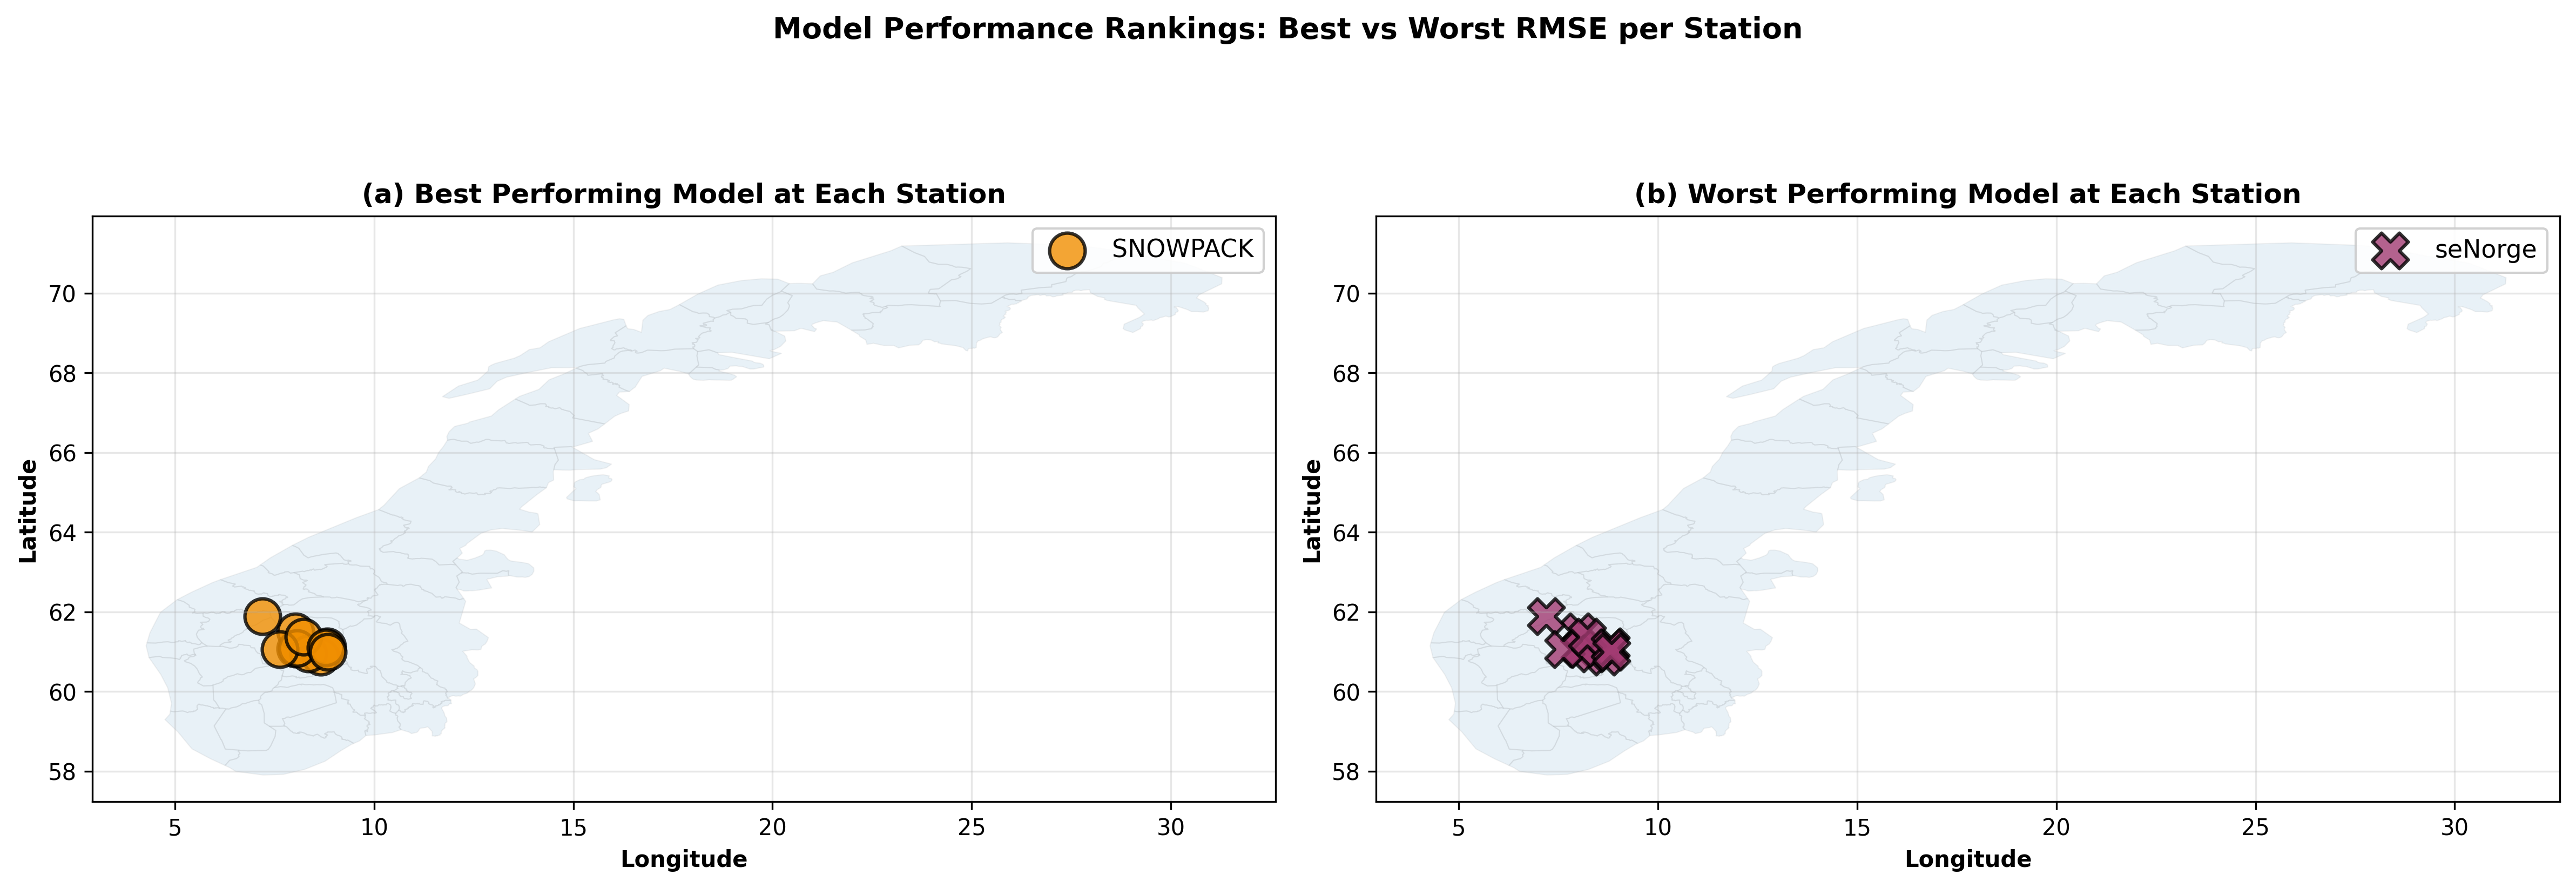

In [15]:
# Create map showing best vs worst model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors for models
model_colors = {'FSM2': '#2E86AB', 'seNorge': '#A23B72', 'SNOWPACK': '#F18F01'}

# Best model map
ax = axes[0]
if regions_gdf is not None:
    regions_gdf.plot(ax=ax, alpha=0.1, edgecolor='gray', linewidth=0.5)

for model in stations_gdf['best_model_name'].unique():
    mask = stations_gdf['best_model_name'] == model
    ax.scatter(stations_gdf[mask].geometry.x, stations_gdf[mask].geometry.y,
              label=model, s=250, color=model_colors.get(model, 'gray'),
              edgecolors='black', linewidth=1.5, alpha=0.8, marker='o')

ax.set_xlabel('Longitude', fontweight='bold')
ax.set_ylabel('Latitude', fontweight='bold')
ax.set_title('(a) Best Performing Model at Each Station', fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Worst model map
ax = axes[1]
if regions_gdf is not None:
    regions_gdf.plot(ax=ax, alpha=0.1, edgecolor='gray', linewidth=0.5)

for model in stations_gdf['worst_model_name'].unique():
    mask = stations_gdf['worst_model_name'] == model
    ax.scatter(stations_gdf[mask].geometry.x, stations_gdf[mask].geometry.y,
              label=model, s=250, color=model_colors.get(model, 'gray'),
              edgecolors='black', linewidth=1.5, alpha=0.8, marker='X')

ax.set_xlabel('Longitude', fontweight='bold')
ax.set_ylabel('Latitude', fontweight='bold')  
ax.set_title('(b) Worst Performing Model at Each Station', fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.suptitle('Model Performance Rankings: Best vs Worst RMSE per Station', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../data/processed/Figure_08_Best_Worst_Models.png', dpi=300, bbox_inches='tight')
print("✓ Figure 8 saved: Figure_08_Best_Worst_Models.png")
plt.show()

## 8b. Zoomed Map: Best vs Worst Model in Jotunheimen

✓ Zoomed best/worst model map saved: Figure_08b_Best_Worst_Models_Zoomed.png


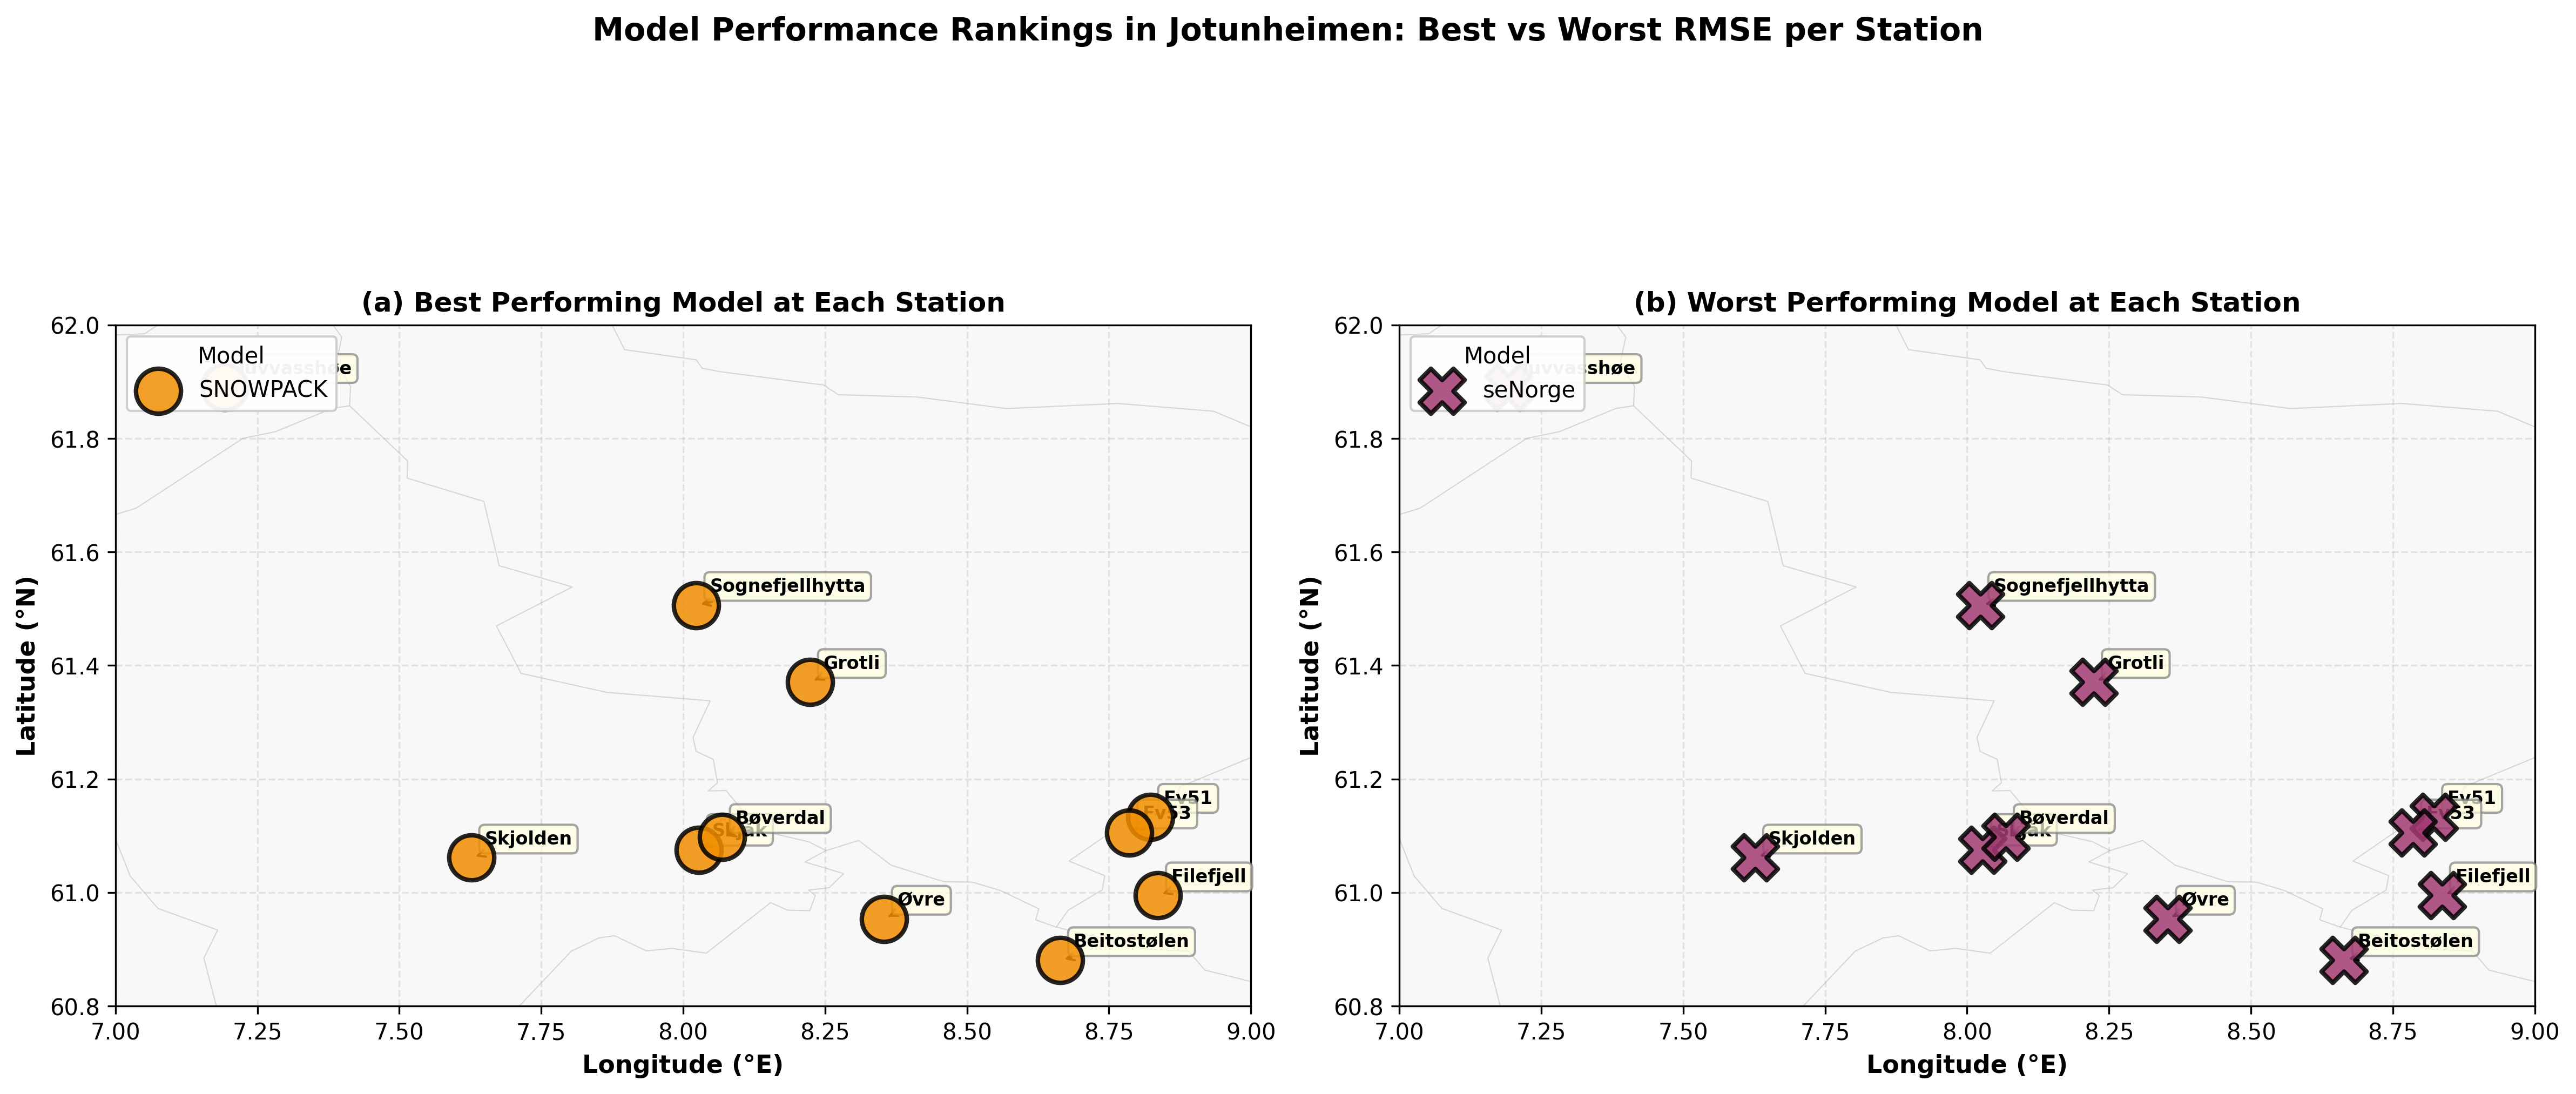

In [16]:
# Create zoomed map of Jotunheimen with best vs worst model
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Define Jotunheimen area bounds
jotun_bounds = {
    'west': 7.0,
    'east': 9.0,
    'south': 60.8,
    'north': 62.0
}

model_colors = {'FSM2': '#2E86AB', 'seNorge': '#A23B72', 'SNOWPACK': '#F18F01'}
markers = {'best': 'o', 'worst': 'X'}  # Circle for best, X for worst

for plot_idx, (ax, model_type) in enumerate(zip(axes, ['best', 'worst'])):
    # Plot background
    if regions_gdf is not None:
        regions_subset = regions_gdf.cx[jotun_bounds['west']:jotun_bounds['east'], 
                                        jotun_bounds['south']:jotun_bounds['north']]
        regions_subset.plot(ax=ax, alpha=0.15, edgecolor='gray', linewidth=0.5, color='lightgray')
    
    # Plot pixels
    if pixels_gdf is not None:
        try:
            pixels_subset = pixels_gdf.cx[jotun_bounds['west']:jotun_bounds['east'], 
                                          jotun_bounds['south']:jotun_bounds['north']]
            pixels_subset.plot(ax=ax, alpha=0.05, edgecolor='lightgray', linewidth=0.2, color='gray')
        except:
            pass
    
    # Plot stations by best/worst model
    if model_type == 'best':
        model_col = 'best_model_name'
        title_text = '(a) Best Performing Model at Each Station'
        marker_symbol = 'o'
    else:
        model_col = 'worst_model_name'
        title_text = '(b) Worst Performing Model at Each Station'
        marker_symbol = 'X'
    
    for model in stations_gdf[model_col].unique():
        mask = stations_gdf[model_col] == model
        stations_subset = stations_gdf[mask]
        
        ax.scatter(stations_subset.geometry.x, stations_subset.geometry.y,
                  label=model, s=400, color=model_colors.get(model, 'gray'),
                  edgecolors='black', linewidth=2, alpha=0.85, marker=marker_symbol, zorder=5)
    
    # Add station labels
    for idx, row in stations_gdf.iterrows():
        ax.annotate(row['Station'].split()[0],  # Just first word of station name
                   xy=(row.geometry.x, row.geometry.y),
                   xytext=(6, 6),
                   textcoords='offset points',
                   fontsize=8,
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7, edgecolor='gray'),
                   arrowprops=dict(arrowstyle='->', lw=1))
    
    # Set extent to Jotunheimen
    ax.set_xlim(jotun_bounds['west'], jotun_bounds['east'])
    ax.set_ylim(jotun_bounds['south'], jotun_bounds['north'])
    
    # Formatting
    ax.set_xlabel('Longitude (°E)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Latitude (°N)', fontweight='bold', fontsize=11)
    ax.set_title(title_text, fontweight='bold', fontsize=12)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95, title='Model')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal')

plt.suptitle('Model Performance Rankings in Jotunheimen: Best vs Worst RMSE per Station', 
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../data/processed/Figure_08b_Best_Worst_Models_Zoomed.png', dpi=300, bbox_inches='tight')
print("✓ Zoomed best/worst model map saved: Figure_08b_Best_Worst_Models_Zoomed.png")
plt.show()


## 9. Summary Statistics from Spatial Analysis

In [17]:
print("\n" + "="*80)
print("SPATIAL ANALYSIS SUMMARY")
print("="*80)

print(f"\nStudy Area: Jotunheimen")
print(f"Number of validation stations: {len(stations_gdf)}")
print(f"Latitude range: {stations_gdf.geometry.y.min():.2f}° - {stations_gdf.geometry.y.max():.2f}°")
print(f"Longitude range: {stations_gdf.geometry.x.min():.2f}° - {stations_gdf.geometry.x.max():.2f}°")

print("\nSpatial patterns in model performance:")
if 'best_model_name' in stations_gdf.columns:
    print("\nBest model distribution:")
    for model, count in stations_gdf['best_model_name'].value_counts().items():
        pct = 100 * count / len(stations_gdf)
        print(f"  {model}: {count} stations ({pct:.1f}%)")

print("\nRMSE statistics across all stations:")
for col in rmse_cols_available:
    model_name = col.replace('_RMSE', '')
    print(f"\n  {model_name}:")
    print(f"    Min: {stations_gdf[col].min():.4f} m")
    print(f"    Max: {stations_gdf[col].max():.4f} m")
    print(f"    Mean: {stations_gdf[col].mean():.4f} m")
    print(f"    Std: {stations_gdf[col].std():.4f} m")

print("\n" + "="*80)


SPATIAL ANALYSIS SUMMARY

Study Area: Jotunheimen
Number of validation stations: 11
Latitude range: 60.88° - 61.89°
Longitude range: 7.19° - 8.84°

Spatial patterns in model performance:

Best model distribution:
  SNOWPACK: 11 stations (100.0%)

RMSE statistics across all stations:

  FSM2:
    Min: 1.0928 m
    Max: 2.1975 m
    Mean: 1.8452 m
    Std: 0.3811 m

  seNorge:
    Min: 1.2165 m
    Max: 2.3413 m
    Mean: 1.9901 m
    Std: 0.3829 m

  SNOWPACK:
    Min: 0.6171 m
    Max: 1.7655 m
    Mean: 1.4127 m
    Std: 0.3800 m



## 10. Export Spatial Data for Further Analysis

In [18]:
# Save stations GeoDataFrame
stations_gdf.to_file('../data/processed/validation_stations_spatial.geojson', driver='GeoJSON')
print("✓ Spatial data saved: validation_stations_spatial.geojson")

# Save as CSV with coordinates
stations_export = stations_gdf.copy()
stations_export['geometry'] = stations_export['geometry'].astype(str)
stations_export.to_csv('../data/processed/validation_stations_with_coordinates.csv', index=False)
print("✓ Station data saved: validation_stations_with_coordinates.csv")

print("\n" + "="*80)
print("SPATIAL ANALYSIS COMPLETE")
print("="*80)
print("\nGenerated figures:")
print("  - Figure_05_Spatial_RMSE_Distribution.png")
print("  - Figure_06_Spatial_Bias_Distribution.png")
print("  - Figure_07_Spatial_Correlation_Distribution.png")
print("  - Figure_08_Best_Worst_Models.png")
print("\nExported data:")
print("  - validation_stations_spatial.geojson")
print("  - validation_stations_with_coordinates.csv")
print("="*80)

✓ Spatial data saved: validation_stations_spatial.geojson
✓ Station data saved: validation_stations_with_coordinates.csv

SPATIAL ANALYSIS COMPLETE

Generated figures:
  - Figure_05_Spatial_RMSE_Distribution.png
  - Figure_06_Spatial_Bias_Distribution.png
  - Figure_07_Spatial_Correlation_Distribution.png
  - Figure_08_Best_Worst_Models.png

Exported data:
  - validation_stations_spatial.geojson
  - validation_stations_with_coordinates.csv


In [19]:
df_station = df[df["station_name"] == "Beitostølen Ii"].copy()
df_station = df_station.sort_index()
df_station = df_station.groupby(df_station.index).mean(numeric_only=True)

obs_xr = xr.DataArray(
    df_station["snow_depth"],
    coords={"time": df_station.index},
    dims=["time"],
    name="snow_depth"
)

NameError: name 'df' is not defined

In [ ]:
x0 = float(fsm_sd.x.mean())
y0 = float(fsm_sd.y.mean())

fsm_ts = fsm_sd.sel(x=x0, y=y0, method="nearest")
senorge_ts = senorge_sd.sel(x=x0, y=y0, method="nearest")

NameError: name 'fsm_sd' is not defined

In [ ]:
obs_ts, fsm_ts, senorge_ts = xr.align(obs_xr, fsm_ts, senorge_ts, join="inner")

In [ ]:
print("OBS max:", float(obs_ts.max()))
print("FSM2 max:", float(fsm_ts.max()))
print("seNorge max:", float(senorge_ts.max()))

NameError: name 'obs_ts' is not defined

In [ ]:
print("OBS peak:", obs_ts.idxmax().values)
print("FSM2 peak:", fsm_ts.idxmax().values)
print("seNorge peak:", senorge_ts.idxmax().values)